## cell type propotion hclust

In [ ]:
# Fig. S2 cell type constitution groups -----------------------------------------------------------------

library(Seurat) #‘4.1.1’
library(dplyr)  #‘1.0.9’
library(patchwork) # ‘1.1.1’
library(plotly) #‘4.10.0’
library(ggplot2)  #‘3.3.6’
#library(clusterProfiler)  #‘4.5.2’

df=read.table('/home/qyyuan/project/Lifei-Spatial/analysis/Part_2_discovery_cohort_CN_definition/Allsubtypes.csv',sep=',',header = TRUE)
result <- df %>%
  # 1. 确保数字列是因子类型，这样即使某些组缺少某个数字(如没有5)，列也会保留
  mutate(celltype = factor(celltype, levels = 1:17)) %>%count(Class, celltype) %>%group_by(Class) %>%
  mutate(
    total = sum(n),           # 该组的总数
    percent = n / total * 100 # 计算百分比
  ) %>%
  ungroup() %>%
  select(Class, celltype, count = n, percent)
wide_result <- result[,c(1,2,4)] %>%
  pivot_wider(names_from = celltype, values_from = percent, values_fill = 0)

df_base <- as.data.frame(wide_result)

# 2. 将第一列 (Class) 设置为行名
rownames(df_base) <- df_base$Class

# 3. 删除原来的第一列（因为现在它已经是行名了，保留会重复）
df_base$Class <- NULL
Freq = df_base



In [ ]:
hclust = hclust(dist(Freq))

In [ ]:

## order


patient_order = rownames(Freq)[hclust$order]

Freq = Freq[patient_order,]

## heatmap for annotation
rownames(Freq) = factor(rownames(Freq), levels = rownames(Freq))




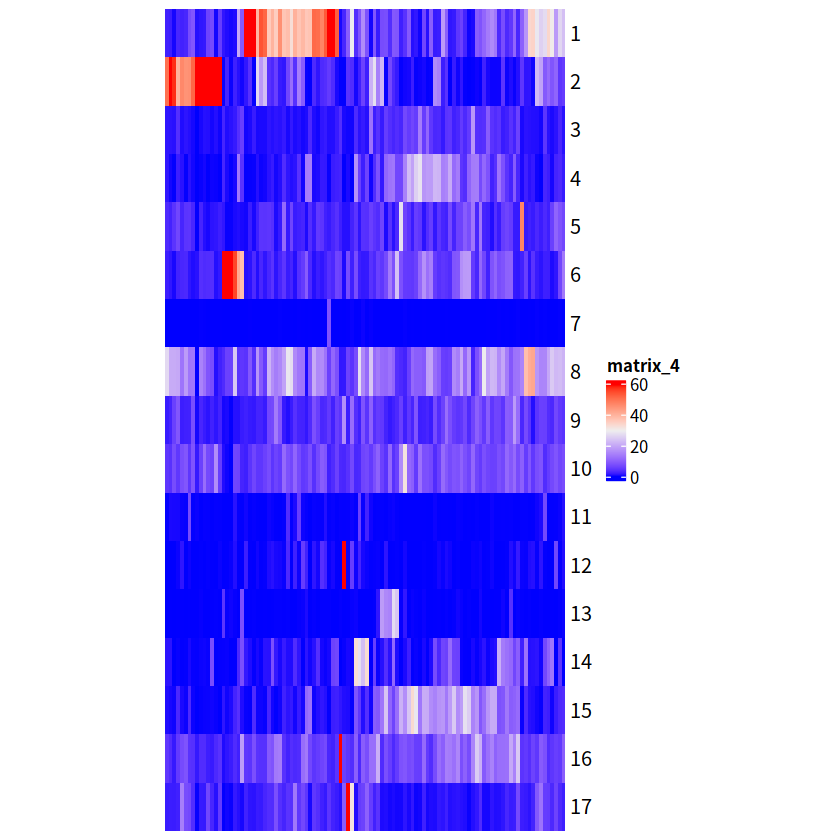

In [ ]:


#scales::show_col(ggsci::pal_aaas("default", alpha = 0.5)(9))
mycolor = RColorBrewer::brewer.pal(12, "Paired")
my_colors <- c(
  "#8358CF", # 1 (原 B cells 色)
  "#AE2519", # 2 (原 Biliary 色)
  "#D083FF", # 3 (原 CD4+ 色)
  "#27A7FA", # 4 (原 CD8+ 色)
  "#F6D026", # 5 (原 Endothelial 色)
  "#74F882", # 6 (原 Fibroblasts 色)
  "#EE6600", # 7 (原 Lymphatic 色)
  "#62FFFF", # 8 (原 Macrophages 色 - 注意这个青色在白色背景可能看不清，建议微调为 #00CED1)
  "#FA339A", # 9 (原 Tumor 色)
  # --- 以下为补充的 8 个颜色 (风格协调) ---
  "#5C4033", # 10 (深棕，区分度高)
  "#8B008B", # 11 (深紫)
  "#2E8B57", # 12 (海绿)
  "#FF7F50", # 13 (珊瑚红)
  "#4682B4", # 14 (钢蓝)
  "#D2691E", # 15 (巧克力色)
  "#006400", # 16 (深绿)
  "#9932CC"  # 17 (暗兰)
)

ComplexHeatmap::Heatmap(t(as.matrix(Freq)), #bottom_annotation = annotation_col_ha,
                        cluster_columns = F,
                        cluster_rows = F,
                        show_column_names = F,
                        width = ncol(t(as.matrix(Freq)))*unit(0.8, "mm")) # 16x12

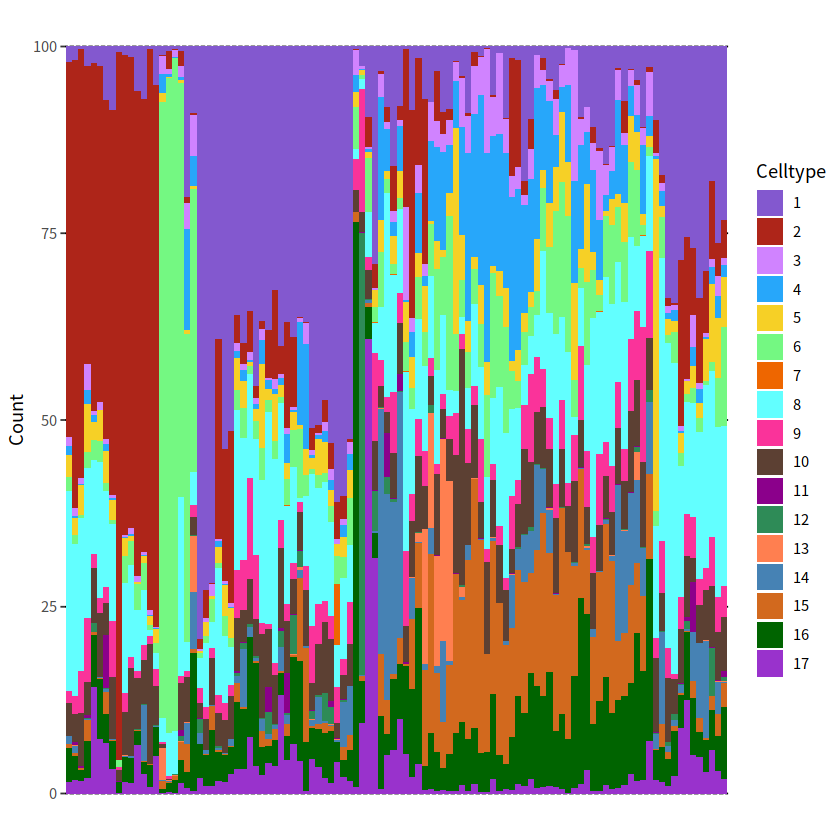

In [ ]:
## barplot
Freq_melt = Freq
Freq_melt$Patient = rownames(Freq_melt)
# Freq_melt = Freq_melt[order(Freq_melt$`Tumor cells`, decreasing = T),]
Freq_melt$Patient = factor(Freq_melt$Patient, levels = Freq_melt$Patient)
Freq_melt <- reshape2::melt(Freq_melt, id.vars=c("Patient"), variable.name="Celltype", value.name="Count")
Freq_melt = Freq_melt[order(Freq_melt$Patient),]

ggplot(data = Freq_melt, aes(x = Patient, y = Count, fill = Celltype)) + 
  geom_bar(stat = "identity", position = "stack", width = 1) + 
  theme(panel.grid.major.y = element_line(colour = "black"),
        panel.background = element_blank(),
        axis.line.x = element_blank(),
        axis.title.x = element_blank(),
        axis.ticks.x = element_blank()) +
  scale_x_discrete(labels = NULL) +
  #theme(axis.text.x = element_text(angle=40, hjust=1, vjust=1)) + 
  scale_fill_manual(values=my_colors)


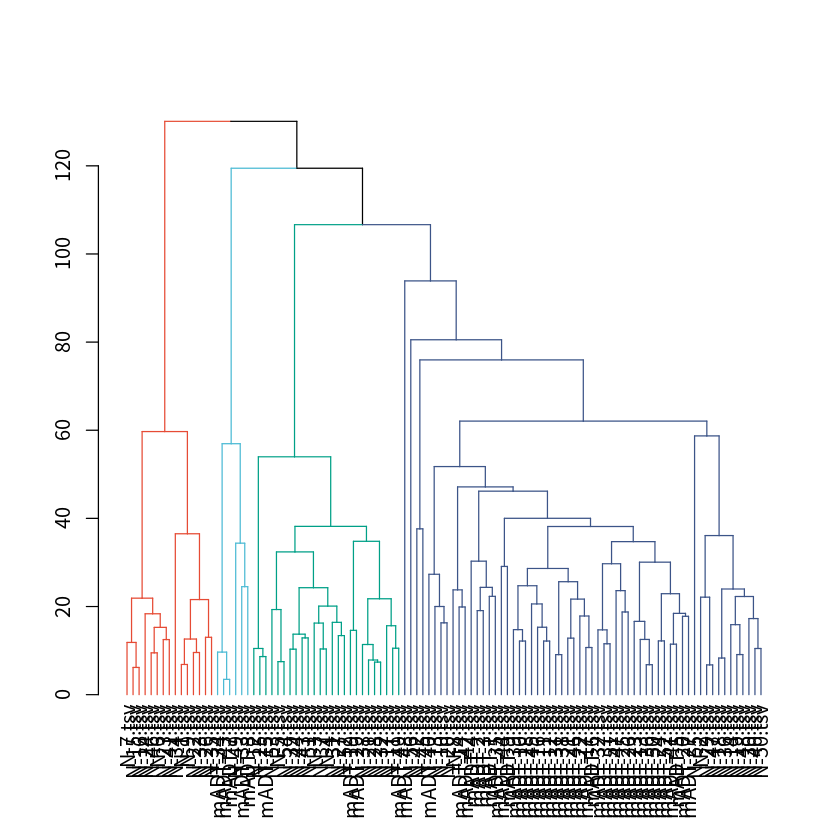

In [ ]:
library(dendextend)
#### relevance analysis ####
hclust = color_branches(hclust,h=100,groupLabels = F,col = ggsci::pal_npg("nrc")(4))
plot(hclust) # 14x2.5 inch

temp = as.data.frame(cutree(hclust, h = 100, order_clusters_as_data = F))
colnames(temp) = "hclust"




In [ ]:
write.table(temp,'Group_4_cell_type_proportion.csv',sep=',',row.names = T,col.names = T,quote = F)

In [ ]:
write.table(Freq,'cell_type_composition.txt',sep='\t',quote=F)

In [ ]:
sample_names <- rownames(Freq)
labels <- ifelse(grepl("^mADT", sample_names), 0, 
          ifelse(grepl("^N-", sample_names) | grepl("^N\\.tsv", sample_names), 1, NA))

if (any(is.na(labels))) {
  warning("发现未识别的样本前缀：")
  print(sample_names[is.na(labels)])
}

# 2. 创建标签数据框 (推荐做法：保存为独立文件)
label_df <- data.frame(
  SampleID = sample_names,
  GroupLabel = labels,
  GroupName = ifelse(labels == 0, "mADT", "N"), # 可选：添加文字名称
  stringsAsFactors = FALSE
)

# 3. 保存标签到 CSV 文件
write.csv(label_df, "treatment_labels.csv", row.names = FALSE,quote=FALSE)

## CN7 and tratmant

In [73]:
X <- read.csv('/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/CN7_composition.txt', row.names = 1,sep='\t')
# label
label1 <- read.csv("CRPC.csv",sep=',')
colnames(label1)=c('Name','CRPC')
label =label1$CRPC

In [74]:
label

[1] 2 1 1 1 1 2 2 1 2 1 2 1 1 2 2 2 1 2 1 2 2 2 2 2 2 2 2 2 2 2 1 1 2 2 2 1 2 2
[39] 2 2 2

In [75]:
celltypes <- colnames(X)
pvals <- c()
log2FC <- c()
for (ct in celltypes) {
  case_vals <- X[label == 1, ct]
  ctrl_vals <- X[label == 0, ct]
  # Wilcoxon test (自动处理 ties 警告)
  p <- wilcox.test(case_vals, ctrl_vals)$p.value
  # log2 fold change
  logfc <- log2(mean(case_vals + 1e-6) / mean(ctrl_vals + 1e-6))
  pvals <- c(pvals, p)
  log2FC <- c(log2FC, logfc)
}
results <- data.frame(
  celltype = celltypes,
  pvalue = pvals,
  log2FC = log2FC
)
results$FDR <- p.adjust(results$pvalue, method = "BH")
# 绘图
library(ggplot2)
library(ggrepel) # egg 通常不需要除非拼多图，这里只画一个图

results$log10FDR <- -log10(results$FDR)

ggplot(results, aes(x = log2FC, y = log10FDR, label = celltype)) +
  geom_point(size = 3) +
  geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "gray") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray") +
  geom_text_repel(max.overlaps = 20) + # 防止标签重叠
  theme_bw() +
  xlab("log2 Fold Change (Case vs Control)") +
  ylab("-log10(FDR)") +
  ggtitle("Volcano plot of cell type differences")


# --- 第二部分：单变量逻辑回归 (已修改：增加全0过滤和错误捕获) ---
logit_results <- data.frame()

for (ct in celltypes) {
  vals <- X[, ct]
  
  # 【必要修改 1】检查是否全为 0 或常数 (唯一值数量为 1)
  if (length(unique(vals)) == 1) {
    message(paste("跳过:", ct, "(数值无变化/全为0)"))
    next 
  }
  
  df <- data.frame(
    label = factor(label),
    value = vals
  )
  
  # 【必要修改 2】使用 tryCatch 防止模型不收敛导致脚本中断
  tryCatch({
    model <- glm(label ~ value, data = df, family = binomial)
    summary_model <- summary(model)
    
    beta <- summary_model$coefficients[2, 1]
    pval <- summary_model$coefficients[2, 4]
    
    # 额外检查：如果系数是 Inf 或 NaN，也跳过
    if (is.infinite(beta) || is.nan(pval)) {
      message(paste("跳过:", ct, "(系数发散)"))
      next
    }
    
    logit_results <- rbind(logit_results,
                           data.frame(celltype = ct,
                                      beta = beta,
                                      pvalue = pval,
                                      stringsAsFactors = FALSE))
  }, error = function(e) {
    message(paste("跳过:", ct, "(报错:", e$message, ")"))
  })
}

# 【必要修改 3】只有当有结果时才计算 FDR
if (nrow(logit_results) > 0) {
  logit_results$FDR <- p.adjust(logit_results$pvalue, method = "BH")
  print("逻辑回归完成，有效结果行数:")
  print(nrow(logit_results))
  print(head(logit_results[order(logit_results$FDR), ])) # 按 FDR 排序查看
} else {
  warning("所有细胞类型均未通过检查，logit_results 为空。")
}
# --- 第三部分：箱线图 (保持原样) ---
library(tidyr)
library(dplyr)
df_long <- X %>%
  mutate(sample = rownames(X),
         condition = label) %>%
  pivot_longer(cols = all_of(celltypes),
               names_to = "celltype",
               values_to = "proportion")

df_long$condition <- as.factor(df_long$condition)
ggplot(df_long, aes(x = condition, y = proportion, fill = condition)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  facet_wrap(~celltype, scales = "free_y") +
  theme_bw() +
  theme(strip.text = element_text(size = 10))

ERROR: Error in wilcox.test.default(case_vals, ctrl_vals): 'y'观察值数量不够


## cn7 and tratment

In [3]:
# 方法一：如果你安装了 tidyverse (推荐)
library(tidyverse)

# 或者 方法二：如果你只想要 dplyr
# library(dplyr)

# 然后再次运行你的数据处理代码
df <- read.table('/home/qyyuan/project/Lifei-Spatial/analysis/Part_2_discovery_cohort_CN_definition/cells_r=50_CN=7.csv', sep=',', header = TRUE)

result <- df %>%
  mutate(celltype = factor(neighborhood10, levels = 0:39)) %>%
  count(Class, neighborhood10) %>%
  group_by(Class) %>%
  mutate(
    total = sum(n),           # 该组的总数 
    percent = n / total * 100 # 计算百分比 
  ) %>%
  ungroup() %>%
  select(Class, neighborhood10, count = n, percent)

wide_result <- result[,c(1,2,4)] %>%
  pivot_wider(names_from = neighborhood10, values_from = percent, values_fill = 0)

df_base <- as.data.frame(wide_result)

# 2. 将第一列 (Class) 设置为行名
rownames(df_base) <- df_base$Class

# 3. 删除原来的第一列
df_base$Class <- NULL

Freq <- df_base

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.2
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [4]:
result

Class,neighborhood10,count,percent
<chr>,<int>,<int>,<dbl>
N-1.tsv,0,23,0.17727763
N-1.tsv,1,10410,80.23739787
N-1.tsv,2,148,1.14074302
N-1.tsv,3,1952,15.04547557
N-1.tsv,4,222,1.71111454
N-1.tsv,5,219,1.68799137
N-10.tsv,0,1835,10.73601685
N-10.tsv,1,497,2.90779312
N-10.tsv,2,114,0.66697870


In [2]:
df=read.table('/home/qyyuan/project/Lifei-Spatial/analysis/Part_2_discovery_cohort_CN_definition/cells_r=50_CN=7.csv',sep=',',header = TRUE)
result <- df %>%
  mutate(celltype = factor(neighborhood10, levels = 0:39)) %>%count(Class, neighborhood10) %>%group_by(Class) %>%
  mutate(
    total = sum(n),           # 该组的总数 
    percent = n / total * 100 # 计算百分比 
  ) %>%
  ungroup() %>%
  select(Class, neighborhood10, count = n, percent)
wide_result <- result[,c(1,2,4)] %>%
  pivot_wider(names_from = neighborhood10, values_from = percent, values_fill = 0)
df_base <- as.data.frame(wide_result)
# 2. 将第一列 (Class) 设置为行名
rownames(df_base) <- df_base$Class
# 3. 删除原来的第一列（因为现在它已经是行名了，保留会重复）
df_base$Class <- NULL
Freq = df_base

ERROR: Error in df %>% mutate(celltype = factor(neighborhood10, levels = 0:39)) %>% : 没有"%>%"这个函数


In [5]:
write.table(Freq,'CN7_composition.txt',sep='\t',quote=F)

In [6]:
X <- read.csv('CN7_composition.txt', row.names = 1,sep='\t')
label1 <- read.csv("treatment_labels.csv",sep=',')
colnames(label1)=c('Class','Treatment','GroupName')
if (!all(rownames(X) %in% label1$Class)) {
  stop("错误：X 中存在一些行名在 label1$Class 中找不到！")
}
label1_sorted <- label1[match(rownames(X), label1$Class), ]
rownames(label1_sorted) <- NULL
identical(rownames(X), label1_sorted$Class) 
head(label1_sorted)
head(rownames(X))
label =label1_sorted$Treatment

[1] TRUE

,Class,Treatment,GroupName
,<chr>,<int>,<chr>
1,N-1.tsv,1,N
2,N-10.tsv,1,N
3,N-11.tsv,1,N
4,N-12.tsv,1,N
5,N-13.tsv,1,N
6,N-14.tsv,1,N


[1] "N-1.tsv"  "N-10.tsv" "N-11.tsv" "N-12.tsv" "N-13.tsv" "N-14.tsv"

Warning message:
“程辑包‘ggrepel’是用R版本4.3.3 来建造的”
Warning message:
“glm.fit:拟合機率算出来是数值零或一”


[1] "逻辑回归完成，有效结果行数:"
[1] 7
  celltype        beta       pvalue          FDR
5       X4 -0.05342654 4.776892e-08 3.343825e-07
1       X0  0.04010652 1.075601e-04 3.764604e-04
4       X3  0.07230828 2.634409e-04 6.146954e-04
6       X5 -0.08103509 6.333914e-03 1.108435e-02
2       X1  0.06358657 1.033110e-02 1.446355e-02
3       X2 -0.03220240 1.063671e-01 1.240949e-01


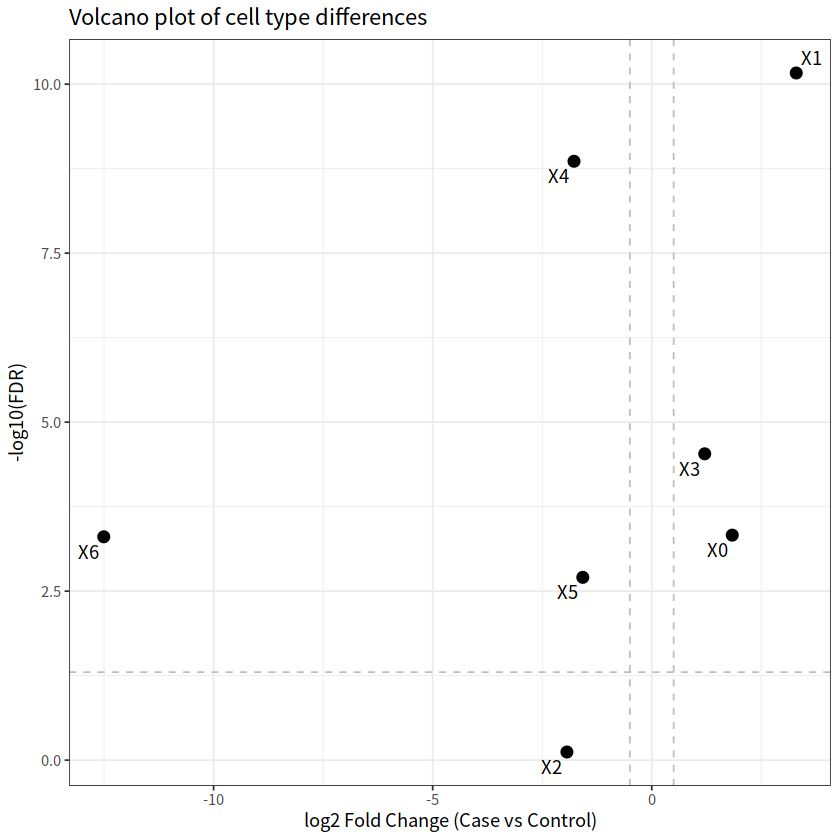

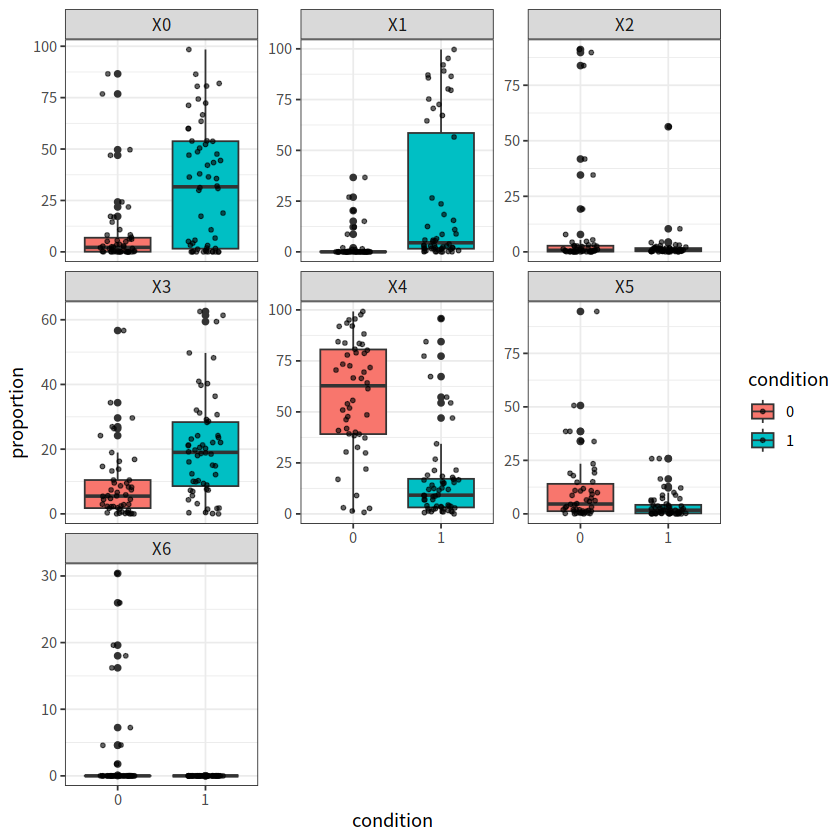

In [7]:
celltypes <- colnames(X)
pvals <- c()
log2FC <- c()
for (ct in celltypes) {
  case_vals <- X[label == 1, ct]
  ctrl_vals <- X[label == 0, ct]
  # Wilcoxon test (自动处理 ties 警告)
  p <- wilcox.test(case_vals, ctrl_vals)$p.value
  # log2 fold change
  logfc <- log2(mean(case_vals + 1e-6) / mean(ctrl_vals + 1e-6))
  pvals <- c(pvals, p)
  log2FC <- c(log2FC, logfc)
}
results <- data.frame(
  celltype = celltypes,
  pvalue = pvals,
  log2FC = log2FC
)
results$FDR <- p.adjust(results$pvalue, method = "BH")
# 绘图
library(ggplot2)
library(ggrepel) # egg 通常不需要除非拼多图，这里只画一个图

results$log10FDR <- -log10(results$FDR)

ggplot(results, aes(x = log2FC, y = log10FDR, label = celltype)) +
  geom_point(size = 3) +
  geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "gray") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray") +
  geom_text_repel(max.overlaps = 20) + # 防止标签重叠
  theme_bw() +
  xlab("log2 Fold Change (Case vs Control)") +
  ylab("-log10(FDR)") +
  ggtitle("Volcano plot of cell type differences")


# --- 第二部分：单变量逻辑回归 (已修改：增加全0过滤和错误捕获) ---
logit_results <- data.frame()

for (ct in celltypes) {
  vals <- X[, ct]
  
  # 【必要修改 1】检查是否全为 0 或常数 (唯一值数量为 1)
  if (length(unique(vals)) == 1) {
    message(paste("跳过:", ct, "(数值无变化/全为0)"))
    next 
  }
  
  df <- data.frame(
    label = factor(label),
    value = vals
  )
  
  # 【必要修改 2】使用 tryCatch 防止模型不收敛导致脚本中断
  tryCatch({
    model <- glm(label ~ value, data = df, family = binomial)
    summary_model <- summary(model)
    
    beta <- summary_model$coefficients[2, 1]
    pval <- summary_model$coefficients[2, 4]
    
    # 额外检查：如果系数是 Inf 或 NaN，也跳过
    if (is.infinite(beta) || is.nan(pval)) {
      message(paste("跳过:", ct, "(系数发散)"))
      next
    }
    
    logit_results <- rbind(logit_results,
                           data.frame(celltype = ct,
                                      beta = beta,
                                      pvalue = pval,
                                      stringsAsFactors = FALSE))
  }, error = function(e) {
    message(paste("跳过:", ct, "(报错:", e$message, ")"))
  })
}

# 【必要修改 3】只有当有结果时才计算 FDR
if (nrow(logit_results) > 0) {
  logit_results$FDR <- p.adjust(logit_results$pvalue, method = "BH")
  print("逻辑回归完成，有效结果行数:")
  print(nrow(logit_results))
  print(head(logit_results[order(logit_results$FDR), ])) # 按 FDR 排序查看
} else {
  warning("所有细胞类型均未通过检查，logit_results 为空。")
}
# --- 第三部分：箱线图 (保持原样) ---
library(tidyr)
library(dplyr)
df_long <- X %>%
  mutate(sample = rownames(X),
         condition = label) %>%
  pivot_longer(cols = all_of(celltypes),
               names_to = "celltype",
               values_to = "proportion")

df_long$condition <- as.factor(df_long$condition)
ggplot(df_long, aes(x = condition, y = proportion, fill = condition)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  facet_wrap(~celltype, scales = "free_y") +
  theme_bw() +
  theme(strip.text = element_text(size = 10))

In [9]:
logit_results

celltype,beta,pvalue,FDR
<chr>,<dbl>,<dbl>,<dbl>
X0,0.04010652,1.075601e-04,3.764604e-04
X1,0.06358657,1.033110e-02,1.446355e-02
X2,-0.03220240,1.063671e-01,1.240949e-01
X3,0.07230828,2.634409e-04,6.146954e-04
X4,-0.05342654,4.776892e-08,3.343825e-07
X5,-0.08103509,6.333914e-03,1.108435e-02
X6,-71.83721798,2.466834e-01,2.466834e-01


In [10]:
results

celltype,pvalue,log2FC,FDR,log10FDR
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
X0,2.681928e-04,1.836791,4.693373e-04,3.3285149
X1,9.763223e-12,3.297322,6.834256e-11,10.1653088
X2,7.588824e-01,-1.936721,7.588824e-01,0.1198255
X3,1.260418e-05,1.208809,2.940975e-05,4.5315087
X4,3.949894e-10,-1.774631,1.382463e-09,8.8593465
X5,1.694376e-03,-1.574065,1.976772e-03,2.7040435
X6,3.547990e-04,-12.506927,4.967187e-04,3.3038895


In [8]:
df_long

sample,condition,celltype,proportion
<chr>,<fct>,<chr>,<dbl>
N-1.tsv,1,X0,0.17727763
N-1.tsv,1,X1,80.23739787
N-1.tsv,1,X2,1.14074302
N-1.tsv,1,X3,15.04547557
N-1.tsv,1,X4,1.71111454
N-1.tsv,1,X5,1.68799137
N-1.tsv,1,X6,0.00000000
N-10.tsv,1,X0,10.73601685
N-10.tsv,1,X1,2.90779312


## CN10 and treatment

In [ ]:
df=read.table('/home/qyyuan/project/Lifei-Spatial/analysis/Part_2_discovery_cohort_CN_definition/cells_r=50_CN=10.csv',sep=',',header = TRUE)
result <- df %>%
  mutate(celltype = factor(neighborhood10, levels = 0:9)) %>%count(Class, neighborhood10) %>%group_by(Class) %>%
  mutate(
    total = sum(n),           # 该组的总数
    percent = n / total * 100 # 计算百分比
  ) %>%
  ungroup() %>%
  select(Class, neighborhood10, count = n, percent)
wide_result <- result[,c(1,2,4)] %>%
  pivot_wider(names_from = neighborhood10, values_from = percent, values_fill = 0)
df_base <- as.data.frame(wide_result)
# 2. 将第一列 (Class) 设置为行名
rownames(df_base) <- df_base$Class
# 3. 删除原来的第一列（因为现在它已经是行名了，保留会重复）
df_base$Class <- NULL
Freq = df_base
write.table(Freq,'CN10_composition.txt',sep='\t',quote=F)

In [ ]:
X <- read.csv('CN10_composition.txt', row.names = 1,sep='\t')
label1 <- read.csv("treatment_labels.csv",sep=',')
colnames(label1)=c('Class','Treatment','GroupName')
if (!all(rownames(X) %in% label1$Class)) { 
  stop("错误：X 中存在一些行名在 label1$Class 中找不到！")
}
label1_sorted <- label1[match(rownames(X), label1$Class), ]
rownames(label1_sorted) <- NULL
identical(rownames(X), label1_sorted$Class) 
head(label1_sorted)
head(rownames(X))
label =label1_sorted$Treatment

[1] TRUE

,Class,Treatment,GroupName
,<chr>,<int>,<chr>
1,N-1.tsv,1,N
2,N-10.tsv,1,N
3,N-11.tsv,1,N
4,N-12.tsv,1,N
5,N-13.tsv,1,N
6,N-14.tsv,1,N


[1] "N-1.tsv"  "N-10.tsv" "N-11.tsv" "N-12.tsv" "N-13.tsv" "N-14.tsv"

Warning message:
“glm.fit:拟合機率算出来是数值零或一”


[1] "逻辑回归完成，有效结果行数:"
[1] 10
   celltype        beta       pvalue          FDR
6        X8 -0.13997856 8.718471e-07 8.718471e-06
1        X0  0.03928588 2.075307e-04 1.037654e-03
2        X2  0.10180180 7.084942e-04 1.950837e-03
5        X5  0.07545062 7.803350e-04 1.950837e-03
8        X6 -0.62217546 1.303077e-03 2.606154e-03
10       X1 -0.98859358 6.301240e-03 1.050207e-02


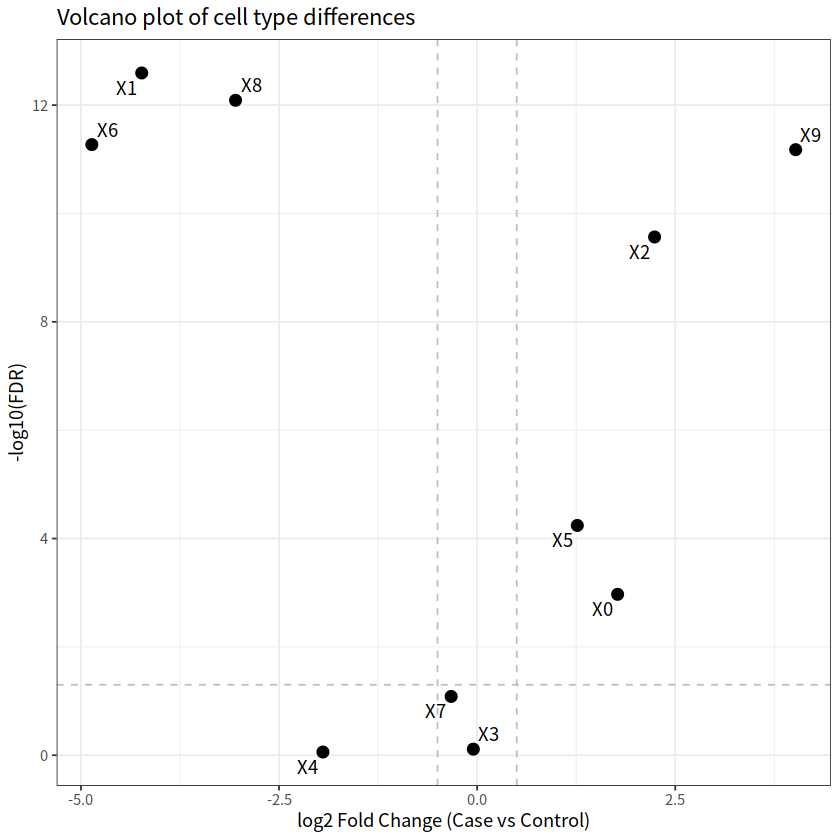

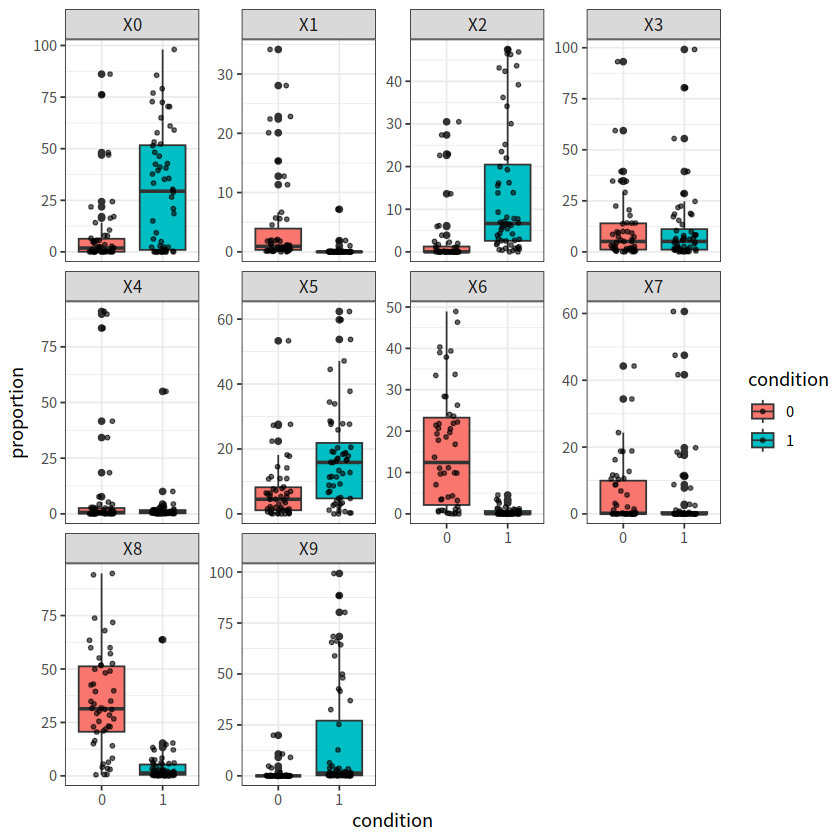

In [ ]:
celltypes <- colnames(X)
pvals <- c()
log2FC <- c()
for (ct in celltypes) {
  case_vals <- X[label == 1, ct]
  ctrl_vals <- X[label == 0, ct]
  # Wilcoxon test (自动处理 ties 警告)
  p <- wilcox.test(case_vals, ctrl_vals)$p.value
  # log2 fold change
  logfc <- log2(mean(case_vals + 1e-6) / mean(ctrl_vals + 1e-6))
  pvals <- c(pvals, p)
  log2FC <- c(log2FC, logfc)
}
results <- data.frame(
  celltype = celltypes,
  pvalue = pvals,
  log2FC = log2FC
)
results$FDR <- p.adjust(results$pvalue, method = "BH")
# 绘图
library(ggplot2)
library(ggrepel) # egg 通常不需要除非拼多图，这里只画一个图

results$log10FDR <- -log10(results$FDR)

ggplot(results, aes(x = log2FC, y = log10FDR, label = celltype)) +
  geom_point(size = 3) +
  geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "gray") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray") +
  geom_text_repel(max.overlaps = 20) + # 防止标签重叠
  theme_bw() +
  xlab("log2 Fold Change (Case vs Control)") +
  ylab("-log10(FDR)") +
  ggtitle("Volcano plot of cell type differences")


# --- 第二部分：单变量逻辑回归 (已修改：增加全0过滤和错误捕获) ---
logit_results <- data.frame()

for (ct in celltypes) {
  vals <- X[, ct]
  
  # 【必要修改 1】检查是否全为 0 或常数 (唯一值数量为 1)
  if (length(unique(vals)) == 1) {
    message(paste("跳过:", ct, "(数值无变化/全为0)"))
    next 
  }
  
  df <- data.frame(
    label = factor(label),
    value = vals
  )
  
  # 【必要修改 2】使用 tryCatch 防止模型不收敛导致脚本中断
  tryCatch({
    model <- glm(label ~ value, data = df, family = binomial)
    summary_model <- summary(model)
    
    beta <- summary_model$coefficients[2, 1]
    pval <- summary_model$coefficients[2, 4]
    
    # 额外检查：如果系数是 Inf 或 NaN，也跳过
    if (is.infinite(beta) || is.nan(pval)) {
      message(paste("跳过:", ct, "(系数发散)"))
      next
    }
    
    logit_results <- rbind(logit_results,
                           data.frame(celltype = ct,
                                      beta = beta,
                                      pvalue = pval,
                                      stringsAsFactors = FALSE))
  }, error = function(e) {
    message(paste("跳过:", ct, "(报错:", e$message, ")"))
  })
}

# 【必要修改 3】只有当有结果时才计算 FDR
if (nrow(logit_results) > 0) {
  logit_results$FDR <- p.adjust(logit_results$pvalue, method = "BH")
  print("逻辑回归完成，有效结果行数:")
  print(nrow(logit_results))
  print(head(logit_results[order(logit_results$FDR), ])) # 按 FDR 排序查看
} else {
  warning("所有细胞类型均未通过检查，logit_results 为空。")
}
# --- 第三部分：箱线图 (保持原样) ---
library(tidyr)
library(dplyr)
df_long <- X %>%
  mutate(sample = rownames(X),
         condition = label) %>%
  pivot_longer(cols = all_of(celltypes),
               names_to = "celltype",
               values_to = "proportion")

df_long$condition <- as.factor(df_long$condition)
ggplot(df_long, aes(x = condition, y = proportion, fill = condition)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  facet_wrap(~celltype, scales = "free_y") +
  theme_bw() +
  theme(strip.text = element_text(size = 10))

## cell type and gleason

In [66]:
X <- read.csv('/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/cell_type_composition.txt', row.names = 1,sep='\t')
# label
label1 <- read.csv("/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/gleason.txt",sep='\t')
x_names_clean <- gsub("\\.tsv$", "", rownames(X))
common_ids <- intersect(x_names_clean, label1$Class)
keep_indices <- which(x_names_clean %in% common_ids)
X1 <- X[keep_indices, ]
x1_names_clean <- gsub("\\.tsv$", "", rownames(X1))
labelnew <- label1[match(x1_names_clean, label1$Class), ]
rownames(labelnew) <- NULL
# ---------------------------------------------------------
# 验证结果
# ---------------------------------------------------------
cat("原始 X 行数:", nrow(X), "\n")
cat("原始 label1 行数:", nrow(label1), "\n")
cat("重叠后 X1 行数:", nrow(X1), "\n")
cat("重叠后 labelnew 行数:", nrow(labelnew), "\n")

# 检查前 5 个是否对应
cat("\n前 5 个样本对应检查:\n")
check_df <- data.frame(
  X_RowName = rownames(X1)[1:5],
  Clean_Name = gsub("\\.tsv$", "", rownames(X1))[1:5],
  Label_Class = labelnew$Class[1:5]
)
print(check_df)

# 确认顺序完全一致
if (all(gsub("\\.tsv$", "", rownames(X1)) == labelnew$Class)) {
  cat("\n✅ 成功：X1 和 labelnew 的顺序已完美对齐！\n")
} else {
  cat("\n❌ 错误：顺序未对齐，请检查数据。\n")
}
labelnew$Gleason[labelnew$Gleason == 6] <- 0
labelnew$Gleason[labelnew$Gleason == 8] <- 1
labelnew$Gleason[labelnew$Gleason == 9] <- 1

  # labelnew$Gleason[labelnew$Gleason == 6] <- 0
  # labelnew$Gleason[labelnew$Gleason == 7] <- 1
  # # labelnew$Gleason[labelnew$Gleason == 8] <- 1
  # # labelnew$Gleason[labelnew$Gleason == 9] <- 1

原始 X 行数: 106 
原始 label1 行数: 53 
重叠后 X1 行数: 53 
重叠后 labelnew 行数: 53 

前 5 个样本对应检查:
  X_RowName Clean_Name Label_Class
1   N-7.tsv        N-7         N-7
2  N-15.tsv       N-15        N-15
3  N-16.tsv       N-16        N-16
4  N-24.tsv       N-24        N-24
5  N-46.tsv       N-46        N-46

✅ 成功：X1 和 labelnew 的顺序已完美对齐！


In [51]:
table(labelnew$Gleason)


 0  1  6 
20 27  6 

Warning message:
“glm.fit:拟合機率算出来是数值零或一”
Warning message:
“glm.fit:拟合機率算出来是数值零或一”


[1] "逻辑回归完成，有效结果行数:"
[1] 17
   celltype        beta    pvalue       FDR
3        X3 -0.44777054 0.1381278 0.7331428
8        X8 -0.06459787 0.1725042 0.7331428
12      X12 11.94020548 0.1508669 0.7331428
13      X13 82.06350272 0.1423778 0.7331428
1        X1  0.01435945 0.5180540 0.8583112
5        X5 -0.03231365 0.4974137 0.8583112


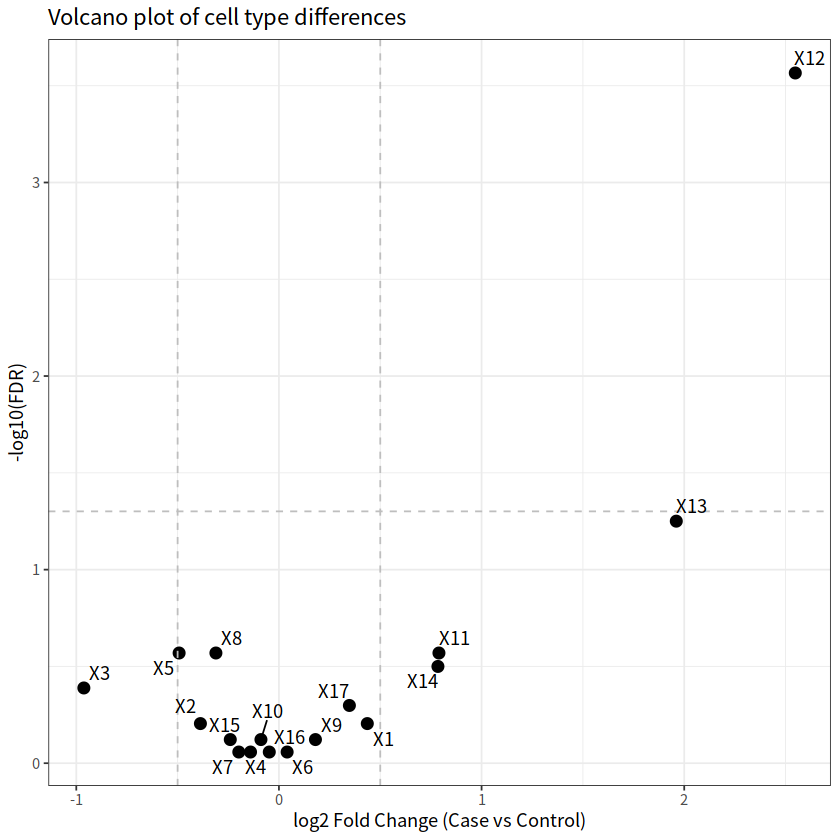

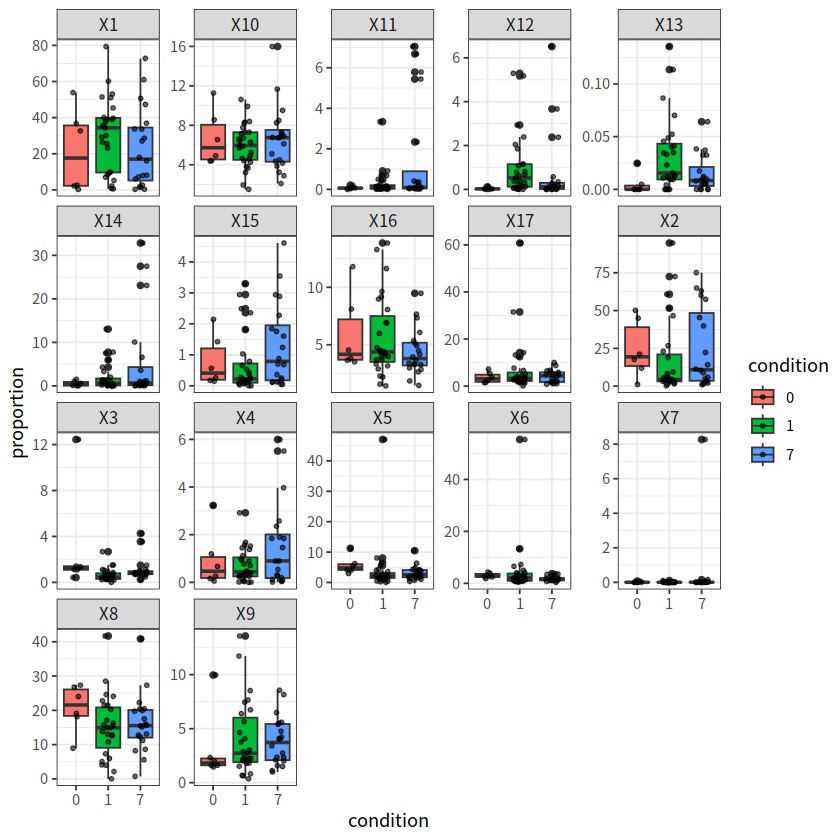

In [67]:
X=X1
# 定义变换函数
asinh_transform <- function(x) {
  # 确保数据在 [0, 1] 之间，防止浮点数误差导致 >1
  x <- pmin(pmax(x, 0), 1) 
  return(asin(sqrt(x)))
}
label= labelnew$Gleason
celltypes <- colnames(X)
pvals <- c()
log2FC <- c()
for (ct in celltypes) {
  case_vals <- X[label == 1, ct]/100
  ctrl_vals <- X[label == 0, ct]/100
  # Wilcoxon test (自动处理 ties 警告)
  case_vals <- asinh_transform(case_vals)
  ctrl_vals <- asinh_transform(ctrl_vals)
  
  # 2. 执行 T 检验 (现在数据更接近正态)
  # var.equal = FALSE 表示使用 Welch's t-test，不假设方差相等，更稳健
  t_res <- t.test(case_vals, ctrl_vals, var.equal = FALSE)
  p <-  t_res$p.value
  # log2 fold change
  logfc <- log2(mean(case_vals + 1e-6) / mean(ctrl_vals + 1e-6))
  pvals <- c(pvals, p)
  log2FC <- c(log2FC, logfc)
}
results <- data.frame(
  celltype = celltypes,
  pvalue = pvals,
  log2FC = log2FC
)
results$FDR <- p.adjust(results$pvalue, method = "BH")
# 绘图
library(ggplot2)
library(ggrepel) # egg 通常不需要除非拼多图，这里只画一个图

results$log10FDR <- -log10(results$FDR)

ggplot(results, aes(x = log2FC, y = log10FDR, label = celltype)) +
  geom_point(size = 3) +
  geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "gray") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray") +
  geom_text_repel(max.overlaps = 20) + # 防止标签重叠
  theme_bw() +
  xlab("log2 Fold Change (Case vs Control)") +
  ylab("-log10(FDR)") +
  ggtitle("Volcano plot of cell type differences")


# --- 第二部分：单变量逻辑回归 (已修改：增加全0过滤和错误捕获) ---
logit_results <- data.frame()

for (ct in celltypes) {
  vals <- X[, ct]
  
  # 【必要修改 1】检查是否全为 0 或常数 (唯一值数量为 1)
  if (length(unique(vals)) == 1) {
    message(paste("跳过:", ct, "(数值无变化/全为0)"))
    next 
  }
  
  df <- data.frame(
    label = factor(label),
    value = vals
  )
  
  # 【必要修改 2】使用 tryCatch 防止模型不收敛导致脚本中断
  tryCatch({
    model <- glm(label ~ value, data = df, family = binomial)
    summary_model <- summary(model)
    
    beta <- summary_model$coefficients[2, 1]
    pval <- summary_model$coefficients[2, 4]
    
    # 额外检查：如果系数是 Inf 或 NaN，也跳过
    if (is.infinite(beta) || is.nan(pval)) {
      message(paste("跳过:", ct, "(系数发散)"))
      next
    }
    
    logit_results <- rbind(logit_results,
                           data.frame(celltype = ct,
                                      beta = beta,
                                      pvalue = pval,
                                      stringsAsFactors = FALSE))
  }, error = function(e) {
    message(paste("跳过:", ct, "(报错:", e$message, ")"))
  })
}

# 【必要修改 3】只有当有结果时才计算 FDR
if (nrow(logit_results) > 0) {
  logit_results$FDR <- p.adjust(logit_results$pvalue, method = "BH")
  print("逻辑回归完成，有效结果行数:")
  print(nrow(logit_results))
  print(head(logit_results[order(logit_results$FDR), ])) # 按 FDR 排序查看
} else {
  warning("所有细胞类型均未通过检查，logit_results 为空。")
}
# --- 第三部分：箱线图 (保持原样) ---
library(tidyr)
library(dplyr)
df_long <- X %>%
  mutate(sample = rownames(X),
         condition = label) %>%
  pivot_longer(cols = all_of(celltypes),
               names_to = "celltype",
               values_to = "proportion")

df_long$condition <- as.factor(df_long$condition)
ggplot(df_long, aes(x = condition, y = proportion, fill = condition)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  facet_wrap(~celltype, scales = "free_y") +
  theme_bw() +
  theme(strip.text = element_text(size = 10))

In [68]:
logit_results

celltype,beta,pvalue,FDR
<chr>,<dbl>,<dbl>,<dbl>
X1,0.014359446,0.5180540,0.8583112
X2,-0.006033142,0.7150779,0.8779342
X3,-0.447770538,0.1381278,0.7331428
X4,0.092411729,0.8028532,0.8890532
X5,-0.032313652,0.4974137,0.8583112
X6,0.009709030,0.8890532,0.8890532
X7,0.580301291,0.8710565,0.8890532
X8,-0.064597875,0.1725042,0.7331428
X9,0.111578757,0.5314245,0.8583112


##CN7 and Gleason

In [69]:
results

celltype,pvalue,log2FC,FDR,log10FDR
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
X1,3.457201e-01,0.43609320,0.624212226,0.20466773
X2,3.671837e-01,-0.38746158,0.624212226,0.20466773
X3,1.682685e-01,-0.96261407,0.408652034,0.38864634
X4,7.736493e-01,-0.14012143,0.875564749,0.05771173
X5,6.725682e-02,-0.49255969,0.269626806,0.56923693
X6,8.755647e-01,0.04046276,0.875564749,0.05771173
X7,8.428626e-01,-0.19802575,0.875564749,0.05771173
X8,7.757769e-02,-0.31098588,0.269626806,0.56923693
X9,5.497436e-01,0.18018003,0.754961626,0.12207512


In [41]:
X <- read.csv('/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/CN7_composition.txt', row.names = 1,sep='\t')
# label
label1 <- read.csv("/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/gleason.txt",sep='\t')
x_names_clean <- gsub("\\.tsv$", "", rownames(X))
common_ids <- intersect(x_names_clean, label1$Class)
keep_indices <- which(x_names_clean %in% common_ids)
X1 <- X[keep_indices, ]
x1_names_clean <- gsub("\\.tsv$", "", rownames(X1))
labelnew <- label1[match(x1_names_clean, label1$Class), ]
rownames(labelnew) <- NULL
# ---------------------------------------------------------
# 验证结果
# ---------------------------------------------------------
cat("原始 X 行数:", nrow(X), "\n")
cat("原始 label1 行数:", nrow(label1), "\n")
cat("重叠后 X1 行数:", nrow(X1), "\n")
cat("重叠后 labelnew 行数:", nrow(labelnew), "\n")

# 检查前 5 个是否对应
cat("\n前 5 个样本对应检查:\n")
check_df <- data.frame(
  X_RowName = rownames(X1)[1:5],
  Clean_Name = gsub("\\.tsv$", "", rownames(X1))[1:5],
  Label_Class = labelnew$Class[1:5]
)
print(check_df)

# 确认顺序完全一致
if (all(gsub("\\.tsv$", "", rownames(X1)) == labelnew$Class)) {
  cat("\n✅ 成功：X1 和 labelnew 的顺序已完美对齐！\n")
} else {
  cat("\n❌ 错误：顺序未对齐，请检查数据。\n")
}
# labelnew$Gleason[labelnew$Gleason == 6] <- 0
# labelnew$Gleason[labelnew$Gleason == 7] <- 0
# labelnew$Gleason[labelnew$Gleason == 8] <- 1
# labelnew$Gleason[labelnew$Gleason == 9] <- 1

labelnew$Gleason[labelnew$Gleason == 6] <- 0
labelnew$Gleason[labelnew$Gleason == 7] <- 1
# labelnew$Gleason[labelnew$Gleason == 8] <- 1
# labelnew$Gleason[labelnew$Gleason == 9] <- 1

原始 X 行数: 106 
原始 label1 行数: 53 
重叠后 X1 行数: 53 
重叠后 labelnew 行数: 53 

前 5 个样本对应检查:
  X_RowName Clean_Name Label_Class
1  N-10.tsv       N-10        N-10
2  N-11.tsv       N-11        N-11
3  N-12.tsv       N-12        N-12
4  N-13.tsv       N-13        N-13
5  N-14.tsv       N-14        N-14

✅ 成功：X1 和 labelnew 的顺序已完美对齐！


[1] "逻辑回归完成，有效结果行数:"
[1] 7
  celltype         beta    pvalue       FDR
1       X0  0.006159141 0.6856278 0.9214779
2       X1 -0.004141660 0.7309800 0.9214779
3       X2  0.027316800 0.7898382 0.9214779
4       X3 -0.033813635 0.2052599 0.9214779
5       X4  0.054849254 0.3105787 0.9214779
6       X5 -0.048569302 0.4301937 0.9214779


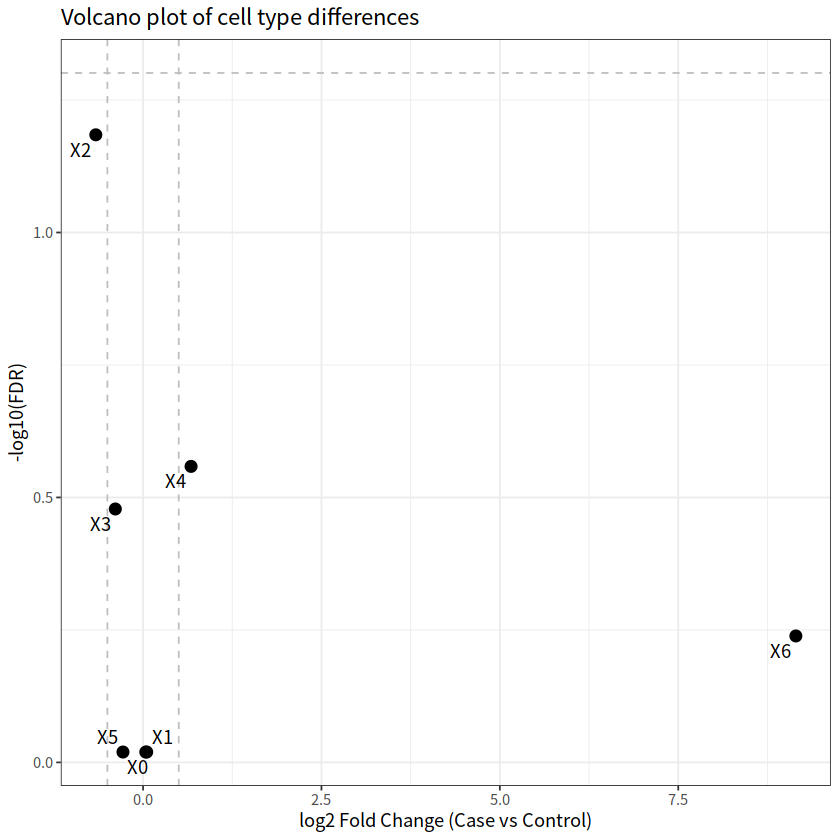

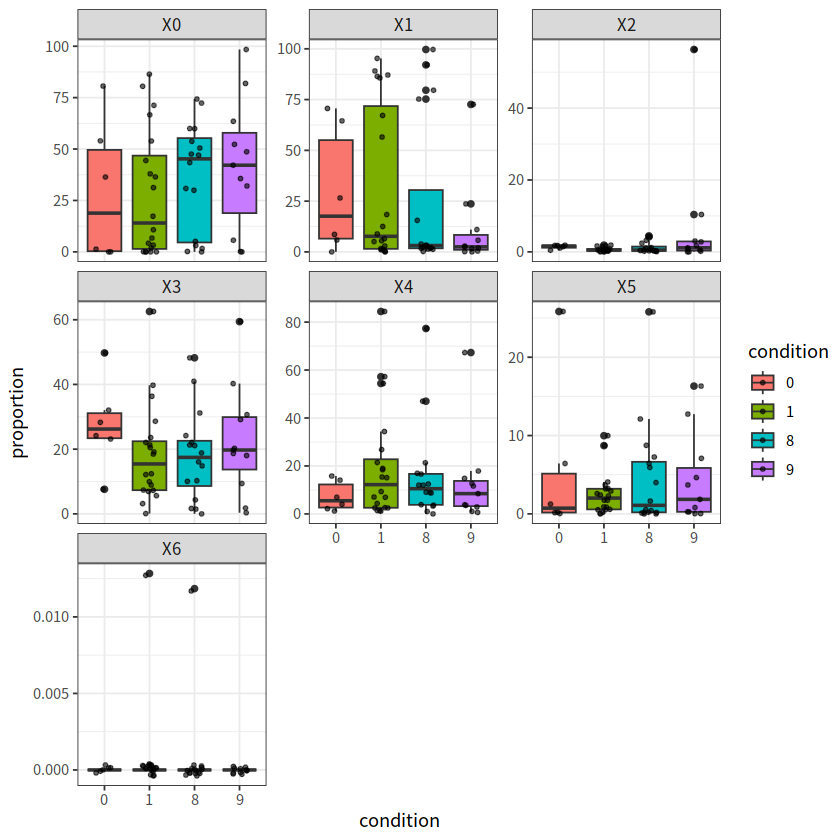

In [42]:
X=X1
# 定义变换函数
asinh_transform <- function(x) {
  # 确保数据在 [0, 1] 之间，防止浮点数误差导致 >1
  x <- pmin(pmax(x, 0), 1) 
  return(asin(sqrt(x)))
}
label= labelnew$Gleason
celltypes <- colnames(X)
pvals <- c()
log2FC <- c()
for (ct in celltypes) {
  case_vals <- X[label == 1, ct]/100
  ctrl_vals <- X[label == 0, ct]/100
  # Wilcoxon test (自动处理 ties 警告)
  case_vals <- asinh_transform(case_vals)
  ctrl_vals <- asinh_transform(ctrl_vals)
  
  # 2. 执行 T 检验 (现在数据更接近正态)
  # var.equal = FALSE 表示使用 Welch's t-test，不假设方差相等，更稳健
  t_res <- t.test(case_vals, ctrl_vals, var.equal = FALSE)
  p <-  t_res$p.value
  # log2 fold change
  logfc <- log2(mean(case_vals + 1e-6) / mean(ctrl_vals + 1e-6))
  pvals <- c(pvals, p)
  log2FC <- c(log2FC, logfc)
}
results <- data.frame(
  celltype = celltypes,
  pvalue = pvals,
  log2FC = log2FC
)
results$FDR <- p.adjust(results$pvalue, method = "BH")
# 绘图
library(ggplot2)
library(ggrepel) # egg 通常不需要除非拼多图，这里只画一个图

results$log10FDR <- -log10(results$FDR)

ggplot(results, aes(x = log2FC, y = log10FDR, label = celltype)) +
  geom_point(size = 3) +
  geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "gray") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray") +
  geom_text_repel(max.overlaps = 20) + # 防止标签重叠
  theme_bw() +
  xlab("log2 Fold Change (Case vs Control)") +
  ylab("-log10(FDR)") +
  ggtitle("Volcano plot of cell type differences")


# --- 第二部分：单变量逻辑回归 (已修改：增加全0过滤和错误捕获) ---
logit_results <- data.frame()

for (ct in celltypes) {
  vals <- X[, ct]
  
  # 【必要修改 1】检查是否全为 0 或常数 (唯一值数量为 1)
  if (length(unique(vals)) == 1) {
    message(paste("跳过:", ct, "(数值无变化/全为0)"))
    next 
  }
  
  df <- data.frame(
    label = factor(label),
    value = vals
  )
  
  # 【必要修改 2】使用 tryCatch 防止模型不收敛导致脚本中断
  tryCatch({
    model <- glm(label ~ value, data = df, family = binomial)
    summary_model <- summary(model)
    
    beta <- summary_model$coefficients[2, 1]
    pval <- summary_model$coefficients[2, 4]
    
    # 额外检查：如果系数是 Inf 或 NaN，也跳过
    if (is.infinite(beta) || is.nan(pval)) {
      message(paste("跳过:", ct, "(系数发散)"))
      next
    }
    
    logit_results <- rbind(logit_results,
                           data.frame(celltype = ct,
                                      beta = beta,
                                      pvalue = pval,
                                      stringsAsFactors = FALSE))
  }, error = function(e) {
    message(paste("跳过:", ct, "(报错:", e$message, ")"))
  })
}

# 【必要修改 3】只有当有结果时才计算 FDR
if (nrow(logit_results) > 0) {
  logit_results$FDR <- p.adjust(logit_results$pvalue, method = "BH")
  print("逻辑回归完成，有效结果行数:")
  print(nrow(logit_results))
  print(head(logit_results[order(logit_results$FDR), ])) # 按 FDR 排序查看
} else {
  warning("所有细胞类型均未通过检查，logit_results 为空。")
}
# --- 第三部分：箱线图 (保持原样) ---
library(tidyr)
library(dplyr)
df_long <- X %>%
  mutate(sample = rownames(X),
         condition = label) %>%
  pivot_longer(cols = all_of(celltypes),
               names_to = "celltype",
               values_to = "proportion")

df_long$condition <- as.factor(df_long$condition)
ggplot(df_long, aes(x = condition, y = proportion, fill = condition)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  facet_wrap(~celltype, scales = "free_y") +
  theme_bw() +
  theme(strip.text = element_text(size = 10))

In [43]:
logit_results

celltype,beta,pvalue,FDR
<chr>,<dbl>,<dbl>,<dbl>
X0,6.159141e-03,0.6856278,0.9214779
X1,-4.141660e-03,0.7309800,0.9214779
X2,2.731680e-02,0.7898382,0.9214779
X3,-3.381363e-02,0.2052599,0.9214779
X4,5.484925e-02,0.3105787,0.9214779
X5,-4.856930e-02,0.4301937,0.9214779
X6,1.272373e+03,0.9955425,0.9955425


In [44]:
results

celltype,pvalue,log2FC,FDR,log10FDR
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
X0,0.955949266,0.03835160,0.95594927,0.01956516
X1,0.927618726,0.05096299,0.95594927,0.01956516
X2,0.009344459,-0.66229476,0.06541122,1.18434778
X3,0.142500287,-0.38860479,0.33250067,0.47820748
X4,0.078947461,0.67274883,0.27631612,0.55859379
X5,0.733839774,-0.28152268,0.95594927,0.01956516
X6,0.329876801,9.14846569,0.57728440,0.23861018


[1] "逻辑回归完成，有效结果行数:"
[1] 7
  celltype         beta    pvalue       FDR
1       X0  0.006159141 0.6856278 0.9214779
2       X1 -0.004141660 0.7309800 0.9214779
3       X2  0.027316800 0.7898382 0.9214779
4       X3 -0.033813635 0.2052599 0.9214779
5       X4  0.054849254 0.3105787 0.9214779
6       X5 -0.048569302 0.4301937 0.9214779


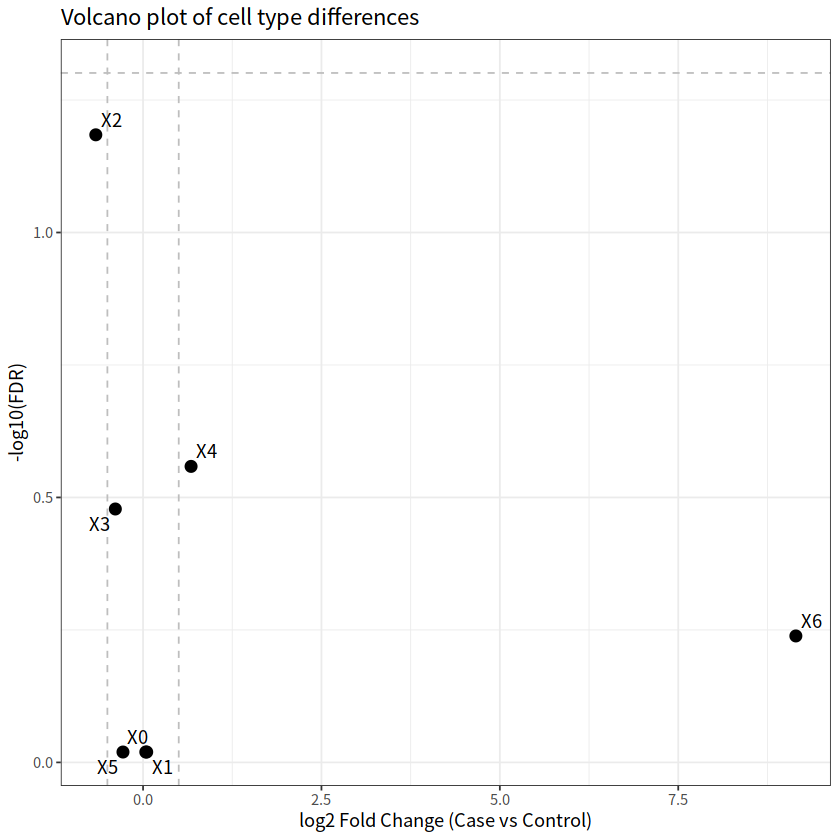

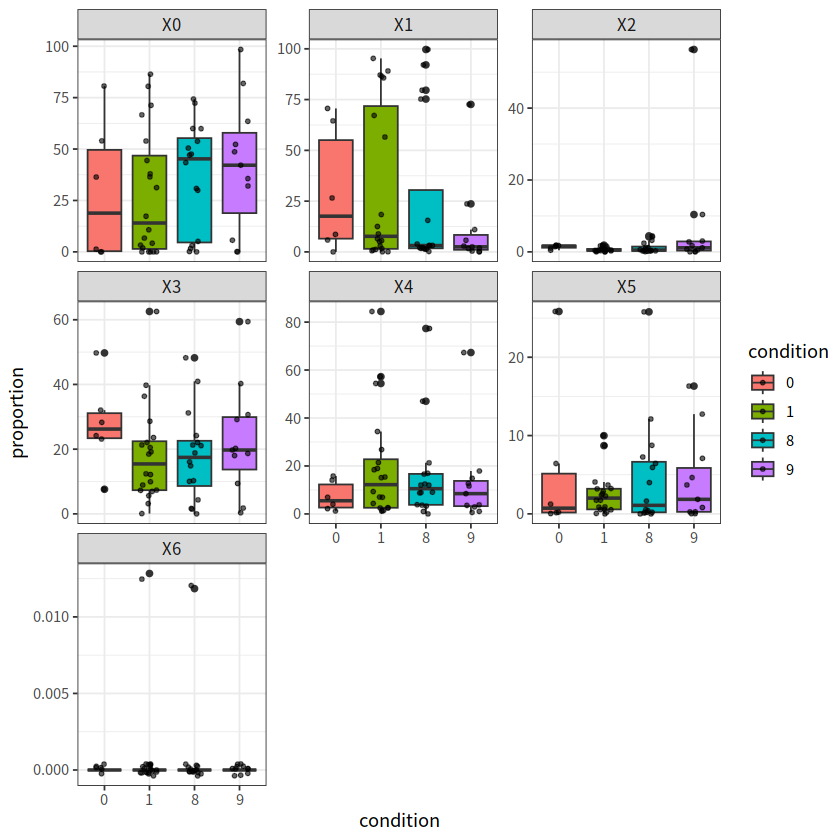

In [30]:
X=X1
# 定义变换函数
asinh_transform <- function(x) {
  # 确保数据在 [0, 1] 之间，防止浮点数误差导致 >1
  x <- pmin(pmax(x, 0), 1) 
  return(asin(sqrt(x)))
}
label= labelnew$Gleason
celltypes <- colnames(X)
pvals <- c()
log2FC <- c()
for (ct in celltypes) {
  case_vals <- X[label == 1, ct]/100
  ctrl_vals <- X[label == 0, ct]/100
  # Wilcoxon test (自动处理 ties 警告)
  case_vals <- asinh_transform(case_vals)
  ctrl_vals <- asinh_transform(ctrl_vals)
  
  # 2. 执行 T 检验 (现在数据更接近正态)
  # var.equal = FALSE 表示使用 Welch's t-test，不假设方差相等，更稳健
  t_res <- t.test(case_vals, ctrl_vals, var.equal = FALSE)
  p <-  t_res$p.value
  # log2 fold change
  logfc <- log2(mean(case_vals + 1e-6) / mean(ctrl_vals + 1e-6))
  pvals <- c(pvals, p)
  log2FC <- c(log2FC, logfc)
}
results <- data.frame(
  celltype = celltypes,
  pvalue = pvals,
  log2FC = log2FC
)
results$FDR <- p.adjust(results$pvalue, method = "BH")
# 绘图
library(ggplot2)
library(ggrepel) # egg 通常不需要除非拼多图，这里只画一个图

results$log10FDR <- -log10(results$FDR)

ggplot(results, aes(x = log2FC, y = log10FDR, label = celltype)) +
  geom_point(size = 3) +
  geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "gray") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray") +
  geom_text_repel(max.overlaps = 20) + # 防止标签重叠
  theme_bw() +
  xlab("log2 Fold Change (Case vs Control)") +
  ylab("-log10(FDR)") +
  ggtitle("Volcano plot of cell type differences")


# --- 第二部分：单变量逻辑回归 (已修改：增加全0过滤和错误捕获) ---
logit_results <- data.frame()

for (ct in celltypes) {
  vals <- X[, ct]
  
  # 【必要修改 1】检查是否全为 0 或常数 (唯一值数量为 1)
  if (length(unique(vals)) == 1) {
    message(paste("跳过:", ct, "(数值无变化/全为0)"))
    next 
  }
  
  df <- data.frame(
    label = factor(label),
    value = vals
  )
  
  # 【必要修改 2】使用 tryCatch 防止模型不收敛导致脚本中断
  tryCatch({
    model <- glm(label ~ value, data = df, family = binomial)
    summary_model <- summary(model)
    
    beta <- summary_model$coefficients[2, 1]
    pval <- summary_model$coefficients[2, 4]
    
    # 额外检查：如果系数是 Inf 或 NaN，也跳过
    if (is.infinite(beta) || is.nan(pval)) {
      message(paste("跳过:", ct, "(系数发散)"))
      next
    }
    
    logit_results <- rbind(logit_results,
                           data.frame(celltype = ct,
                                      beta = beta,
                                      pvalue = pval,
                                      stringsAsFactors = FALSE))
  }, error = function(e) {
    message(paste("跳过:", ct, "(报错:", e$message, ")"))
  })
}

# 【必要修改 3】只有当有结果时才计算 FDR
if (nrow(logit_results) > 0) {
  logit_results$FDR <- p.adjust(logit_results$pvalue, method = "BH")
  print("逻辑回归完成，有效结果行数:")
  print(nrow(logit_results))
  print(head(logit_results[order(logit_results$FDR), ])) # 按 FDR 排序查看
} else {
  warning("所有细胞类型均未通过检查，logit_results 为空。")
}
# --- 第三部分：箱线图 (保持原样) ---
library(tidyr)
library(dplyr)
df_long <- X %>%
  mutate(sample = rownames(X),
         condition = label) %>%
  pivot_longer(cols = all_of(celltypes),
               names_to = "celltype",
               values_to = "proportion")

df_long$condition <- as.factor(df_long$condition)
ggplot(df_long, aes(x = condition, y = proportion, fill = condition)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  facet_wrap(~celltype, scales = "free_y") +
  theme_bw() +
  theme(strip.text = element_text(size = 10))

## CN7 and gleason

In [11]:
X <- read.csv('/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/CN7_composition.txt', row.names = 1,sep='\t')
# label
label1 <- read.csv("/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/gleason.txt",sep='\t')

x_names_clean <- gsub("\\.tsv$", "", rownames(X))
common_ids <- intersect(x_names_clean, label1$Class)
keep_indices <- which(x_names_clean %in% common_ids)
X1 <- X[keep_indices, ]
x1_names_clean <- gsub("\\.tsv$", "", rownames(X1))
labelnew <- label1[match(x1_names_clean, label1$Class), ]
rownames(labelnew) <- NULL

# ---------------------------------------------------------
# 验证结果
# ---------------------------------------------------------
cat("原始 X 行数:", nrow(X), "\n")
cat("原始 label1 行数:", nrow(label1), "\n")
cat("重叠后 X1 行数:", nrow(X1), "\n")
cat("重叠后 labelnew 行数:", nrow(labelnew), "\n")

# 检查前 5 个是否对应
cat("\n前 5 个样本对应检查:\n")
check_df <- data.frame(
  X_RowName = rownames(X1)[1:5],
  Clean_Name = gsub("\\.tsv$", "", rownames(X1))[1:5],
  Label_Class = labelnew$Class[1:5]
)
print(check_df)

# 确认顺序完全一致
if (all(gsub("\\.tsv$", "", rownames(X1)) == labelnew$Class)) {
  cat("\n✅ 成功：X1 和 labelnew 的顺序已完美对齐！\n")
} else {
  cat("\n❌ 错误：顺序未对齐，请检查数据。\n")
}
labelnew$Gleason[labelnew$Gleason == 6] <- 0
labelnew$Gleason[labelnew$Gleason == 7] <- 0
labelnew$Gleason[labelnew$Gleason == 8] <- 1
labelnew$Gleason[labelnew$Gleason == 9] <- 1

原始 X 行数: 106 
原始 label1 行数: 53 
重叠后 X1 行数: 53 
重叠后 labelnew 行数: 53 



前 5 个样本对应检查:
  X_RowName Clean_Name Label_Class
1  N-10.tsv       N-10        N-10
2  N-11.tsv       N-11        N-11
3  N-12.tsv       N-12        N-12
4  N-13.tsv       N-13        N-13
5  N-14.tsv       N-14        N-14

✅ 成功：X1 和 labelnew 的顺序已完美对齐！


Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”


[1] "逻辑回归完成，有效结果行数:"
[1] 7
  celltype         beta    pvalue       FDR
1       X0  0.012562007 0.1930730 0.4632586
2       X1 -0.010735558 0.1985394 0.4632586
3       X2  0.386620412 0.1495204 0.4632586
6       X5  0.040102033 0.4324996 0.7568743
4       X3 -0.002956312 0.8740543 0.9323830
5       X4 -0.004657992 0.7427869 0.9323830


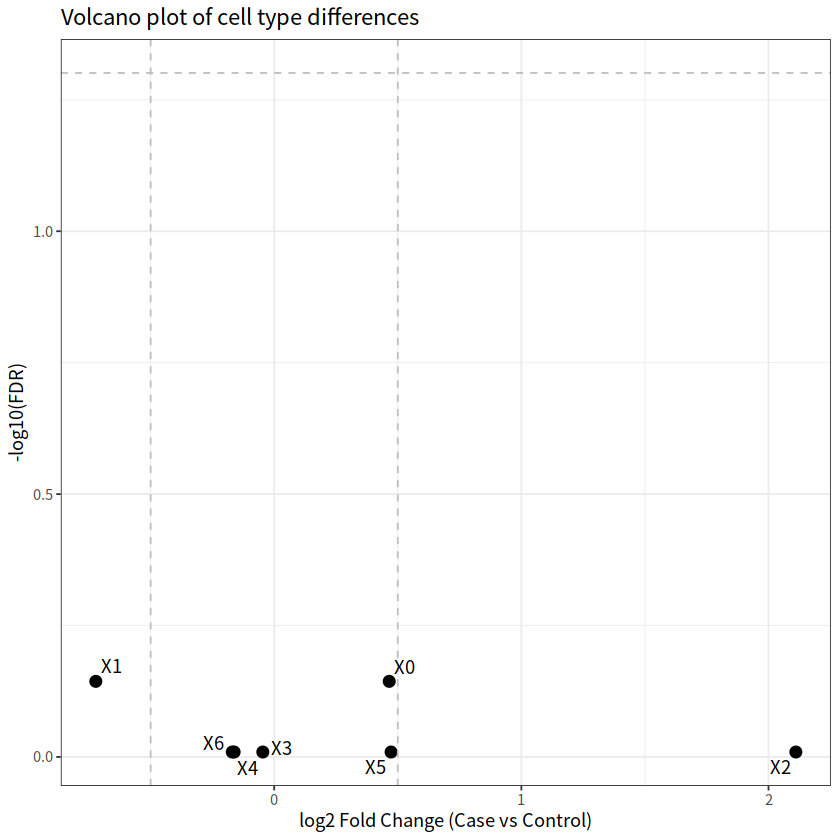

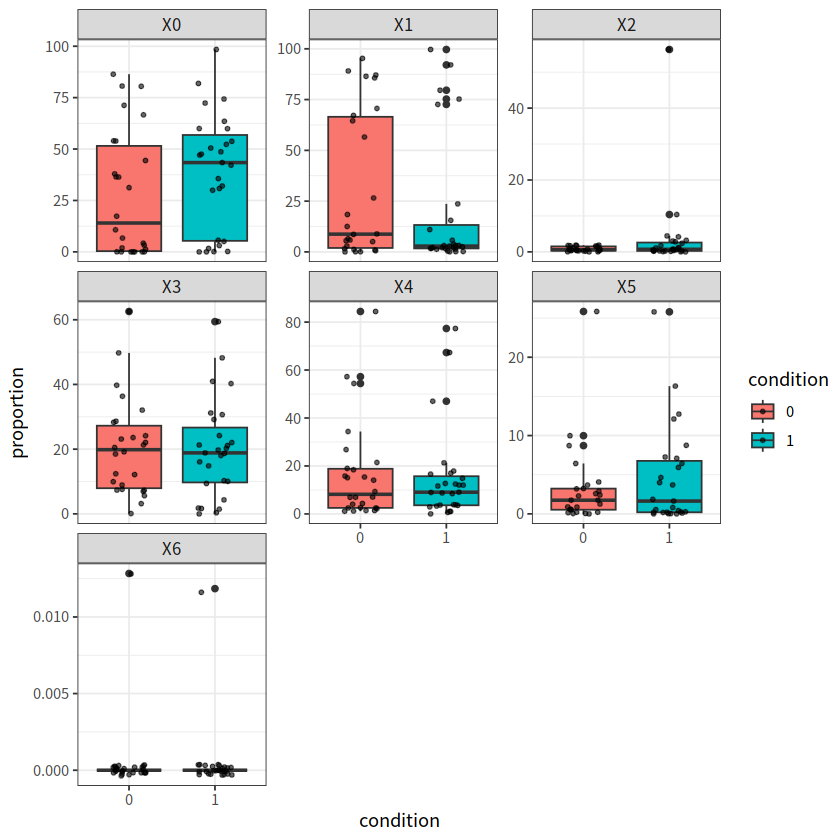

In [12]:
X=X1
label= labelnew$Gleason
celltypes <- colnames(X)
pvals <- c()
log2FC <- c()
for (ct in celltypes) {
  case_vals <- X[label == 1, ct]
  ctrl_vals <- X[label == 0, ct]
  # Wilcoxon test (自动处理 ties 警告)
  p <- wilcox.test(case_vals, ctrl_vals)$p.value
  # log2 fold change
  logfc <- log2(mean(case_vals + 1e-6) / mean(ctrl_vals + 1e-6))
  pvals <- c(pvals, p)
  log2FC <- c(log2FC, logfc)
}
results <- data.frame(
  celltype = celltypes,
  pvalue = pvals,
  log2FC = log2FC
)
results$FDR <- p.adjust(results$pvalue, method = "BH")
# 绘图
library(ggplot2)
library(ggrepel) # egg 通常不需要除非拼多图，这里只画一个图

results$log10FDR <- -log10(results$FDR)

ggplot(results, aes(x = log2FC, y = log10FDR, label = celltype)) +
  geom_point(size = 3) +
  geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "gray") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray") +
  geom_text_repel(max.overlaps = 20) + # 防止标签重叠
  theme_bw() +
  xlab("log2 Fold Change (Case vs Control)") +
  ylab("-log10(FDR)") +
  ggtitle("Volcano plot of cell type differences")


# --- 第二部分：单变量逻辑回归 (已修改：增加全0过滤和错误捕获) ---
logit_results <- data.frame()

for (ct in celltypes) {
  vals <- X[, ct]
  
  # 【必要修改 1】检查是否全为 0 或常数 (唯一值数量为 1)
  if (length(unique(vals)) == 1) {
    message(paste("跳过:", ct, "(数值无变化/全为0)"))
    next 
  }
  
  df <- data.frame(
    label = factor(label),
    value = vals
  )
  
  # 【必要修改 2】使用 tryCatch 防止模型不收敛导致脚本中断
  tryCatch({
    model <- glm(label ~ value, data = df, family = binomial)
    summary_model <- summary(model)
    
    beta <- summary_model$coefficients[2, 1]
    pval <- summary_model$coefficients[2, 4]
    
    # 额外检查：如果系数是 Inf 或 NaN，也跳过
    if (is.infinite(beta) || is.nan(pval)) {
      message(paste("跳过:", ct, "(系数发散)"))
      next
    }
    
    logit_results <- rbind(logit_results,
                           data.frame(celltype = ct,
                                      beta = beta,
                                      pvalue = pval,
                                      stringsAsFactors = FALSE))
  }, error = function(e) {
    message(paste("跳过:", ct, "(报错:", e$message, ")"))
  })
}

# 【必要修改 3】只有当有结果时才计算 FDR
if (nrow(logit_results) > 0) {
  logit_results$FDR <- p.adjust(logit_results$pvalue, method = "BH")
  print("逻辑回归完成，有效结果行数:")
  print(nrow(logit_results))
  print(head(logit_results[order(logit_results$FDR), ])) # 按 FDR 排序查看
} else {
  warning("所有细胞类型均未通过检查，logit_results 为空。")
}
# --- 第三部分：箱线图 (保持原样) ---
library(tidyr)
library(dplyr)
df_long <- X %>%
  mutate(sample = rownames(X),
         condition = label) %>%
  pivot_longer(cols = all_of(celltypes),
               names_to = "celltype",
               values_to = "proportion")

df_long$condition <- as.factor(df_long$condition)
ggplot(df_long, aes(x = condition, y = proportion, fill = condition)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  facet_wrap(~celltype, scales = "free_y") +
  theme_bw() +
  theme(strip.text = element_text(size = 10))

In [14]:
logit_results

celltype,beta,pvalue,FDR
<chr>,<dbl>,<dbl>,<dbl>
X0,0.012562007,0.1930730,0.4632586
X1,-0.010735558,0.1985394,0.4632586
X2,0.386620412,0.1495204,0.4632586
X3,-0.002956312,0.8740543,0.9323830
X4,-0.004657992,0.7427869,0.9323830
X5,0.040102033,0.4324996,0.7568743
X6,-9.910769995,0.9323830,0.9323830


In [15]:
results

celltype,pvalue,log2FC,FDR,log10FDR
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
X0,0.1968974,0.46536902,0.7180169,0.143865307
X1,0.2051477,-0.72186372,0.7180169,0.143865307
X2,0.5423877,2.11069746,0.9785049,0.009437012
X3,0.8117477,-0.04608044,0.9785049,0.009437012
X4,0.7440990,-0.16218963,0.9785049,0.009437012
X5,0.9220403,0.47290970,0.9785049,0.009437012
X6,0.9785049,-0.16972395,0.9785049,0.009437012


## CN7 and gleason

In [24]:
X <- read.csv('/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/CN7_composition.txt', row.names = 1,sep='\t')
# label
label1 <- read.csv("/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/gleason.txt",sep='\t')

x_names_clean <- gsub("\\.tsv$", "", rownames(X))
common_ids <- intersect(x_names_clean, label1$Class)
keep_indices <- which(x_names_clean %in% common_ids)
X1 <- X[keep_indices, ]
x1_names_clean <- gsub("\\.tsv$", "", rownames(X1))
labelnew <- label1[match(x1_names_clean, label1$Class), ]
rownames(labelnew) <- NULL

# ---------------------------------------------------------
# 验证结果
# ---------------------------------------------------------
cat("原始 X 行数:", nrow(X), "\n")
cat("原始 label1 行数:", nrow(label1), "\n")
cat("重叠后 X1 行数:", nrow(X1), "\n")
cat("重叠后 labelnew 行数:", nrow(labelnew), "\n")

# 检查前 5 个是否对应
cat("\n前 5 个样本对应检查:\n")
check_df <- data.frame(
  X_RowName = rownames(X1)[1:5],
  Clean_Name = gsub("\\.tsv$", "", rownames(X1))[1:5],
  Label_Class = labelnew$Class[1:5]
)
print(check_df)

# 确认顺序完全一致
if (all(gsub("\\.tsv$", "", rownames(X1)) == labelnew$Class)) {
  cat("\n✅ 成功：X1 和 labelnew 的顺序已完美对齐！\n")
} else {
  cat("\n❌ 错误：顺序未对齐，请检查数据。\n")
}
labelnew$Gleason[labelnew$Gleason == 6] <- 0
# labelnew$Gleason[labelnew$Gleason == 7] <- 0
labelnew$Gleason[labelnew$Gleason == 8] <- 1
labelnew$Gleason[labelnew$Gleason == 9] <- 1

原始 X 行数: 106 
原始 label1 行数: 53 
重叠后 X1 行数: 53 
重叠后 labelnew 行数: 53 

前 5 个样本对应检查:
  X_RowName Clean_Name Label_Class
1  N-10.tsv       N-10        N-10
2  N-11.tsv       N-11        N-11
3  N-12.tsv       N-12        N-12
4  N-13.tsv       N-13        N-13
5  N-14.tsv       N-14        N-14

✅ 成功：X1 和 labelnew 的顺序已完美对齐！


Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”


[1] "逻辑回归完成，有效结果行数:"
[1] 7
  celltype         beta    pvalue       FDR
1       X0  0.006159141 0.6856278 0.9214779
2       X1 -0.004141660 0.7309800 0.9214779
3       X2  0.027316800 0.7898382 0.9214779
4       X3 -0.033813635 0.2052599 0.9214779
5       X4  0.054849254 0.3105787 0.9214779
6       X5 -0.048569302 0.4301937 0.9214779


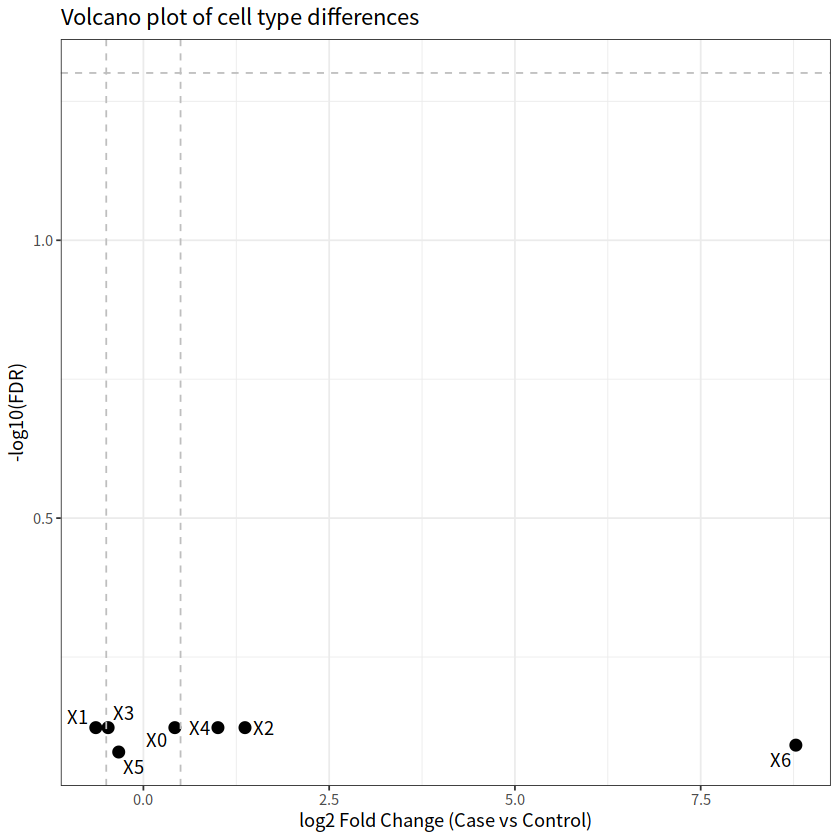

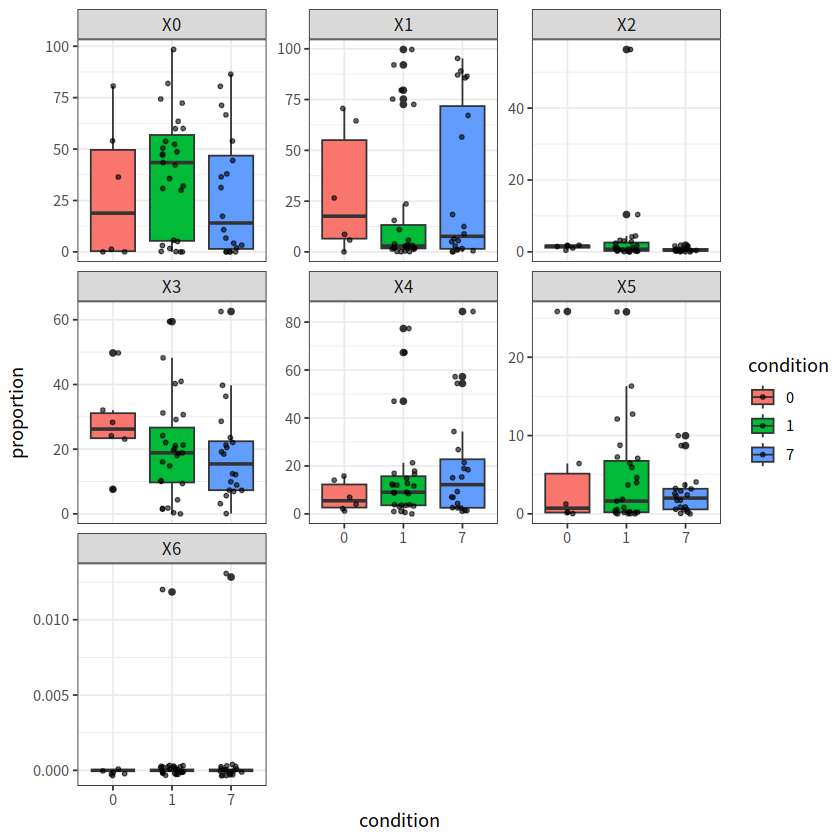

In [25]:
X=X1
label= labelnew$Gleason
celltypes <- colnames(X)
pvals <- c()
log2FC <- c()
for (ct in celltypes) {
  case_vals <- X[label == 1, ct]
  ctrl_vals <- X[label == 0, ct]
  # Wilcoxon test (自动处理 ties 警告)
  p <- wilcox.test(case_vals, ctrl_vals)$p.value
  # log2 fold change
  logfc <- log2(mean(case_vals + 1e-6) / mean(ctrl_vals + 1e-6))
  pvals <- c(pvals, p)
  log2FC <- c(log2FC, logfc)
}
results <- data.frame(
  celltype = celltypes,
  pvalue = pvals,
  log2FC = log2FC
)
results$FDR <- p.adjust(results$pvalue, method = "BH")
# 绘图
library(ggplot2)
library(ggrepel) # egg 通常不需要除非拼多图，这里只画一个图

results$log10FDR <- -log10(results$FDR)

ggplot(results, aes(x = log2FC, y = log10FDR, label = celltype)) +
  geom_point(size = 3) +
  geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "gray") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray") +
  geom_text_repel(max.overlaps = 20) + # 防止标签重叠
  theme_bw() +
  xlab("log2 Fold Change (Case vs Control)") +
  ylab("-log10(FDR)") +
  ggtitle("Volcano plot of cell type differences")


# --- 第二部分：单变量逻辑回归 (已修改：增加全0过滤和错误捕获) ---
logit_results <- data.frame()

for (ct in celltypes) {
  vals <- X[, ct]
  
  # 【必要修改 1】检查是否全为 0 或常数 (唯一值数量为 1)
  if (length(unique(vals)) == 1) {
    message(paste("跳过:", ct, "(数值无变化/全为0)"))
    next 
  }
  
  df <- data.frame(
    label = factor(label),
    value = vals
  )
  
  # 【必要修改 2】使用 tryCatch 防止模型不收敛导致脚本中断
  tryCatch({
    model <- glm(label ~ value, data = df, family = binomial)
    summary_model <- summary(model)
    
    beta <- summary_model$coefficients[2, 1]
    pval <- summary_model$coefficients[2, 4]
    
    # 额外检查：如果系数是 Inf 或 NaN，也跳过
    if (is.infinite(beta) || is.nan(pval)) {
      message(paste("跳过:", ct, "(系数发散)"))
      next
    }
    
    logit_results <- rbind(logit_results,
                           data.frame(celltype = ct,
                                      beta = beta,
                                      pvalue = pval,
                                      stringsAsFactors = FALSE))
  }, error = function(e) {
    message(paste("跳过:", ct, "(报错:", e$message, ")"))
  })
}

# 【必要修改 3】只有当有结果时才计算 FDR
if (nrow(logit_results) > 0) {
  logit_results$FDR <- p.adjust(logit_results$pvalue, method = "BH")
  print("逻辑回归完成，有效结果行数:")
  print(nrow(logit_results))
  print(head(logit_results[order(logit_results$FDR), ])) # 按 FDR 排序查看
} else {
  warning("所有细胞类型均未通过检查，logit_results 为空。")
}
# --- 第三部分：箱线图 (保持原样) ---
library(tidyr)
library(dplyr)
df_long <- X %>%
  mutate(sample = rownames(X),
         condition = label) %>%
  pivot_longer(cols = all_of(celltypes),
               names_to = "celltype",
               values_to = "proportion")

df_long$condition <- as.factor(df_long$condition)
ggplot(df_long, aes(x = condition, y = proportion, fill = condition)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  facet_wrap(~celltype, scales = "free_y") +
  theme_bw() +
  theme(strip.text = element_text(size = 10))

In [26]:
logit_results

celltype,beta,pvalue,FDR
<chr>,<dbl>,<dbl>,<dbl>
X0,6.159141e-03,0.6856278,0.9214779
X1,-4.141660e-03,0.7309800,0.9214779
X2,2.731680e-02,0.7898382,0.9214779
X3,-3.381363e-02,0.2052599,0.9214779
X4,5.484925e-02,0.3105787,0.9214779
X5,-4.856930e-02,0.4301937,0.9214779
X6,1.272373e+03,0.9955425,0.9955425


In [27]:
results

celltype,pvalue,log2FC,FDR,log10FDR
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
X0,0.4693491,0.4234597,0.7535064,0.12291304
X1,0.3020672,-0.6405200,0.7535064,0.12291304
X2,0.3722300,1.3672576,0.7535064,0.12291304
X3,0.1446918,-0.4747128,0.7535064,0.12291304
X4,0.5382189,1.0031489,0.7535064,0.12291304
X5,0.8336212,-0.3321709,0.8336212,0.07903126
X6,0.6944398,8.7806802,0.8101798,0.09141861


results

## cell type and aderson

In [ ]:
X <- read.csv('/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/cell_type_composition.txt', row.names = 1,sep='\t')
# label
label1 <- read.csv("/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/anderson_adt.txt",sep='\t')
x_names_clean <- gsub("^m", "", gsub("\\.tsv$", "", rownames(X)))
common_ids <- intersect(x_names_clean, label1$Class)
cat("发现的重叠样本数量:", length(common_ids), "\n")
cat("示例重叠ID:", head(common_ids), "\n")
keep_indices <- which(x_names_clean %in% common_ids)
X1 <- X[keep_indices, ]
x1_names_clean <- gsub("^m", "", gsub("\\.tsv$", "", rownames(X1)))
labelnew <- label1[match(x1_names_clean, label1$Class), ]
# 重置行名，使其整洁
rownames(labelnew) <- NULL
# ---------------------------------------------------------
# 验证结果
# ---------------------------------------------------------
cat("\n--- 验证结果 ---\n")
cat("X1 行数:", nrow(X1), "\n")
cat("labelnew 行数:", nrow(labelnew), "\n")
# 检查前 5 个对应关系
if (nrow(X1) > 0) {
  check_df <- data.frame(
    X_Original_RowName = rownames(X1)[1:min(5, nrow(X1))],
    X_Clean_Name = x1_names_clean[1:min(5, nrow(X1))],
    Label_Class = labelnew$Class[1:min(5, nrow(labelnew))]
  )
  print(check_df)
  # 最终一致性检查
  if (all(x1_names_clean == labelnew$Class)) {
    cat("\n✅ 成功：X1 和 labelnew 已完美对齐 (ADT/mADT 匹配成功)！\n")
  } else {
    cat("\n❌ 错误：顺序或内容未对齐。\n")
  }
} else {
  cat("\n⚠️ 警告：没有找到任何匹配的样本。请检查 label1$Class 是否真的包含 'ADT-...' 格式。\n")
}

发现的重叠样本数量: 50 
示例重叠ID: ADT-34 ADT-43 ADT-7 ADT-33 ADT-8 ADT-15 

--- 验证结果 ---
X1 行数: 50 
labelnew 行数: 50 
  X_Original_RowName X_Clean_Name Label_Class
1        mADT-34.tsv       ADT-34      ADT-34
2        mADT-43.tsv       ADT-43      ADT-43
3         mADT-7.tsv        ADT-7       ADT-7
4        mADT-33.tsv       ADT-33      ADT-33
5         mADT-8.tsv        ADT-8       ADT-8

✅ 成功：X1 和 labelnew 已完美对齐 (ADT/mADT 匹配成功)！


In [ ]:
labelnew$Anderson[labelnew$Anderson == 1] = 0
labelnew$Anderson[labelnew$Anderson == 2] = 1
label= labelnew$Anderson

Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”


[1] "逻辑回归完成，有效结果行数:"
[1] 17
   celltype        beta     pvalue       FDR
1        X1  0.06763491 0.06303140 0.3550271
4        X4 -0.07659627 0.08353578 0.3550271
5        X5 -0.23438307 0.07088496 0.3550271
9        X9  0.16475161 0.07800908 0.3550271
3        X3 -0.22495881 0.12812012 0.3953103
17      X17  0.40274844 0.13952130 0.3953103


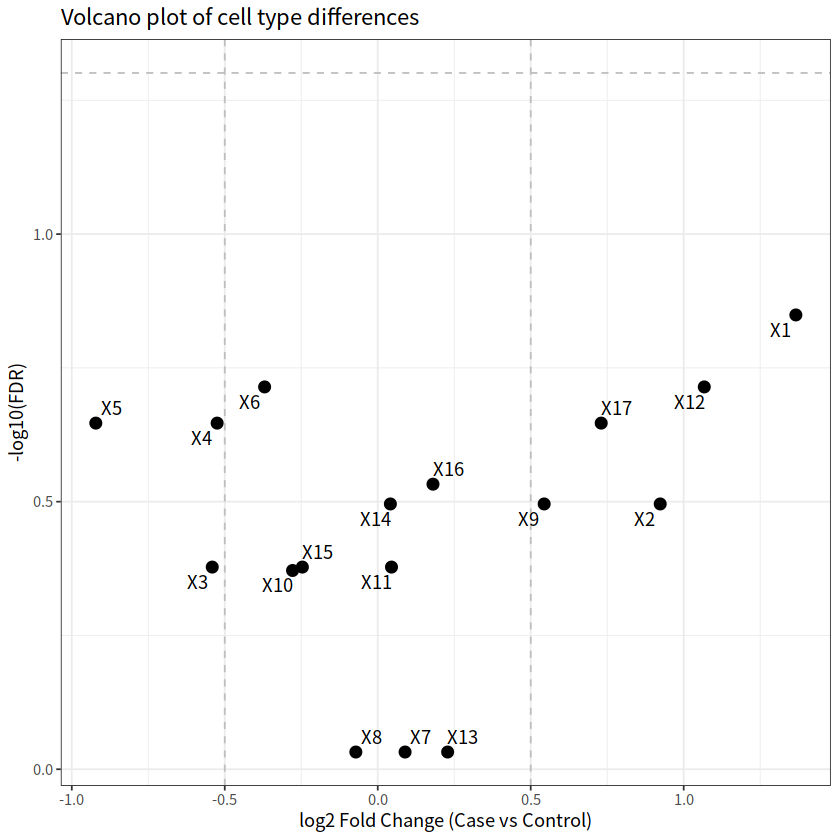

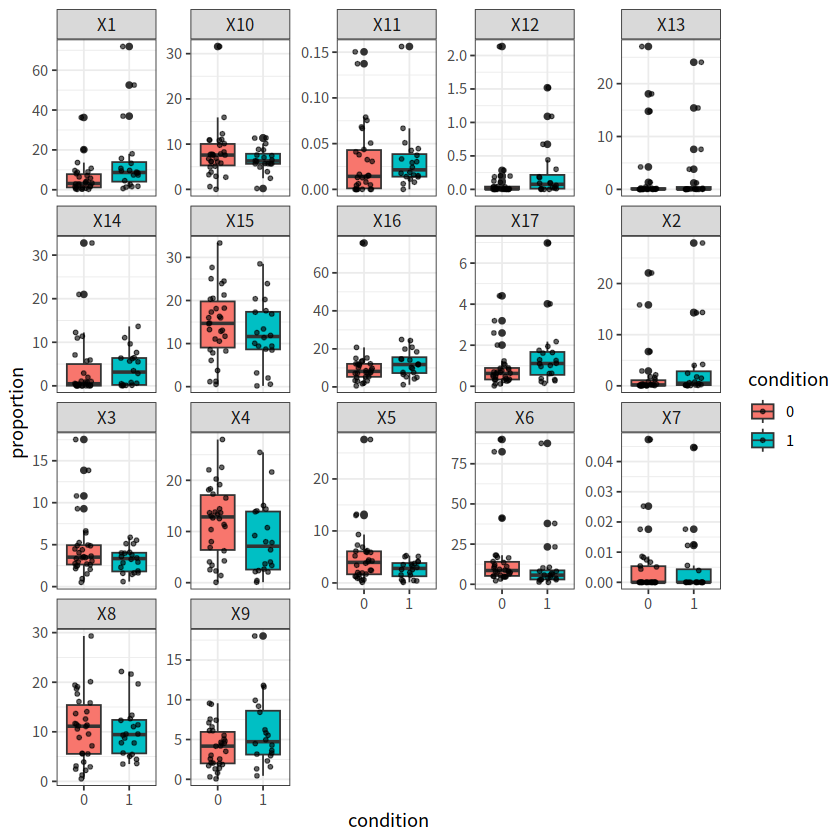

In [ ]:
X=X1
celltypes <- colnames(X)
pvals <- c()
log2FC <- c()
for (ct in celltypes) {
  case_vals <- X[label == 1, ct]
  ctrl_vals <- X[label == 0, ct]
  # Wilcoxon test (自动处理 ties 警告)
  p <- wilcox.test(case_vals, ctrl_vals)$p.value
  # log2 fold change
  logfc <- log2(mean(case_vals + 1e-6) / mean(ctrl_vals + 1e-6))
  pvals <- c(pvals, p)
  log2FC <- c(log2FC, logfc)
}
results <- data.frame(
  celltype = celltypes,
  pvalue = pvals,
  log2FC = log2FC
)
results$FDR <- p.adjust(results$pvalue, method = "BH")
# 绘图
library(ggplot2)
library(ggrepel) # egg 通常不需要除非拼多图，这里只画一个图

results$log10FDR <- -log10(results$FDR)

ggplot(results, aes(x = log2FC, y = log10FDR, label = celltype)) +
  geom_point(size = 3) +
  geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "gray") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray") +
  geom_text_repel(max.overlaps = 20) + # 防止标签重叠
  theme_bw() +
  xlab("log2 Fold Change (Case vs Control)") +
  ylab("-log10(FDR)") +
  ggtitle("Volcano plot of cell type differences")


# --- 第二部分：单变量逻辑回归 (已修改：增加全0过滤和错误捕获) ---
logit_results <- data.frame()

for (ct in celltypes) {
  vals <- X[, ct]
  
  # 【必要修改 1】检查是否全为 0 或常数 (唯一值数量为 1)
  if (length(unique(vals)) == 1) {
    message(paste("跳过:", ct, "(数值无变化/全为0)"))
    next 
  }
  
  df <- data.frame(
    label = factor(label),
    value = vals
  )
  
  # 【必要修改 2】使用 tryCatch 防止模型不收敛导致脚本中断
  tryCatch({
    model <- glm(label ~ value, data = df, family = binomial)
    summary_model <- summary(model)
    
    beta <- summary_model$coefficients[2, 1]
    pval <- summary_model$coefficients[2, 4]
    
    # 额外检查：如果系数是 Inf 或 NaN，也跳过
    if (is.infinite(beta) || is.nan(pval)) {
      message(paste("跳过:", ct, "(系数发散)"))
      next
    }
    
    logit_results <- rbind(logit_results,
                           data.frame(celltype = ct,
                                      beta = beta,
                                      pvalue = pval,
                                      stringsAsFactors = FALSE))
  }, error = function(e) {
    message(paste("跳过:", ct, "(报错:", e$message, ")"))
  })
}

# 【必要修改 3】只有当有结果时才计算 FDR
if (nrow(logit_results) > 0) {
  logit_results$FDR <- p.adjust(logit_results$pvalue, method = "BH")
  print("逻辑回归完成，有效结果行数:")
  print(nrow(logit_results))
  print(head(logit_results[order(logit_results$FDR), ])) # 按 FDR 排序查看
} else {
  warning("所有细胞类型均未通过检查，logit_results 为空。")
}
# --- 第三部分：箱线图 (保持原样) ---
library(tidyr)
library(dplyr)
df_long <- X %>%
  mutate(sample = rownames(X),
         condition = label) %>%
  pivot_longer(cols = all_of(celltypes),
               names_to = "celltype",
               values_to = "proportion")

df_long$condition <- as.factor(df_long$condition)
ggplot(df_long, aes(x = condition, y = proportion, fill = condition)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  facet_wrap(~celltype, scales = "free_y") +
  theme_bw() +
  theme(strip.text = element_text(size = 10))

## CN7 and aderson

In [20]:
X <- read.csv('/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/CN7_composition.txt', row.names = 1,sep='\t')
# label
label1 <- read.csv("/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/anderson_adt.txt",sep='\t')
x_names_clean <- gsub("^m", "", gsub("\\.tsv$", "", rownames(X)))
common_ids <- intersect(x_names_clean, label1$Class)
cat("发现的重叠样本数量:", length(common_ids), "\n")
cat("示例重叠ID:", head(common_ids), "\n")
keep_indices <- which(x_names_clean %in% common_ids)
X1 <- X[keep_indices, ]
x1_names_clean <- gsub("^m", "", gsub("\\.tsv$", "", rownames(X1)))
labelnew <- label1[match(x1_names_clean, label1$Class), ]
# 重置行名，使其整洁
rownames(labelnew) <- NULL
# ---------------------------------------------------------
# 验证结果
# ---------------------------------------------------------
cat("\n--- 验证结果 ---\n")
cat("X1 行数:", nrow(X1), "\n")
cat("labelnew 行数:", nrow(labelnew), "\n")
# 检查前 5 个对应关系
if (nrow(X1) > 0) {
  check_df <- data.frame(
    X_Original_RowName = rownames(X1)[1:min(5, nrow(X1))],
    X_Clean_Name = x1_names_clean[1:min(5, nrow(X1))],
    Label_Class = labelnew$Class[1:min(5, nrow(labelnew))]
  )
  print(check_df)
  # 最终一致性检查
  if (all(x1_names_clean == labelnew$Class)) {
    cat("\n✅ 成功：X1 和 labelnew 已完美对齐 (ADT/mADT 匹配成功)！\n")
  } else {
    cat("\n❌ 错误：顺序或内容未对齐。\n")
  }
} else {
  cat("\n⚠️ 警告：没有找到任何匹配的样本。请检查 label1$Class 是否真的包含 'ADT-...' 格式。\n")
}
labelnew$Anderson[labelnew$Anderson == 1] = 0
labelnew$Anderson[labelnew$Anderson == 2] = 1
label= labelnew$Anderson

发现的重叠样本数量: 50 
示例重叠ID: ADT-1 ADT-10 ADT-11 ADT-12 ADT-13 ADT-14 

--- 验证结果 ---
X1 行数: 50 
labelnew 行数: 50 
  X_Original_RowName X_Clean_Name Label_Class
1         mADT-1.tsv        ADT-1       ADT-1
2        mADT-10.tsv       ADT-10      ADT-10
3        mADT-11.tsv       ADT-11      ADT-11
4        mADT-12.tsv       ADT-12      ADT-12
5        mADT-13.tsv       ADT-13      ADT-13

✅ 成功：X1 和 labelnew 已完美对齐 (ADT/mADT 匹配成功)！


Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”


[1] "逻辑回归完成，有效结果行数:"
[1] 7
  celltype         beta     pvalue       FDR
5       X4 -0.025791812 0.02368999 0.1658299
1       X0  0.047872858 0.07248394 0.2536938
6       X5  0.021565942 0.25397131 0.5925997
2       X1  0.036691024 0.37065594 0.6486479
3       X2 -0.001152287 0.93175670 0.9317567
4       X3 -0.002708854 0.91952224 0.9317567


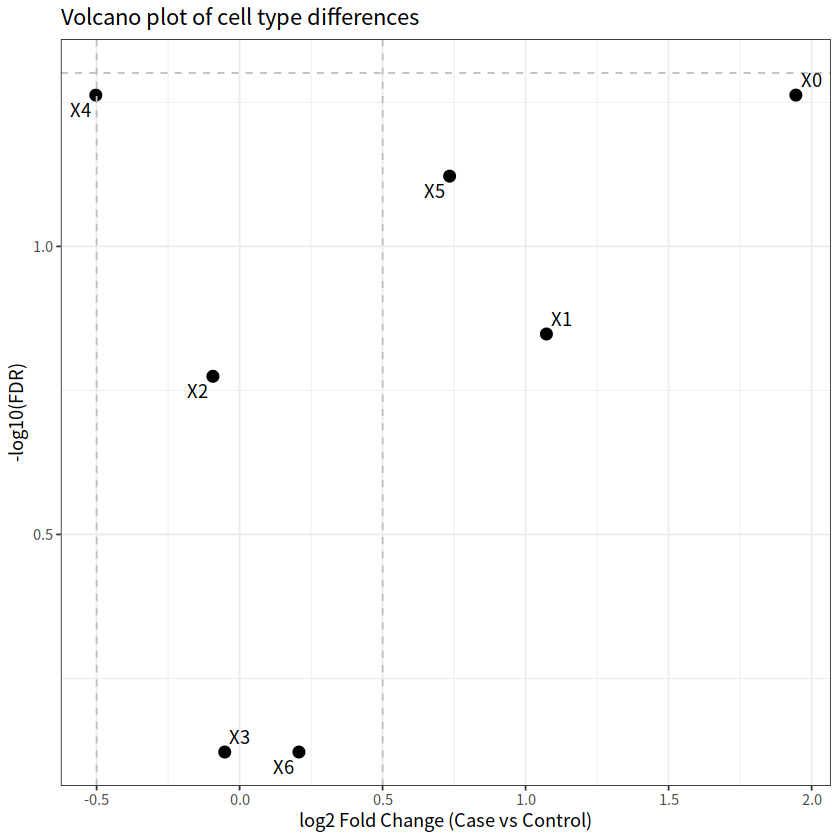

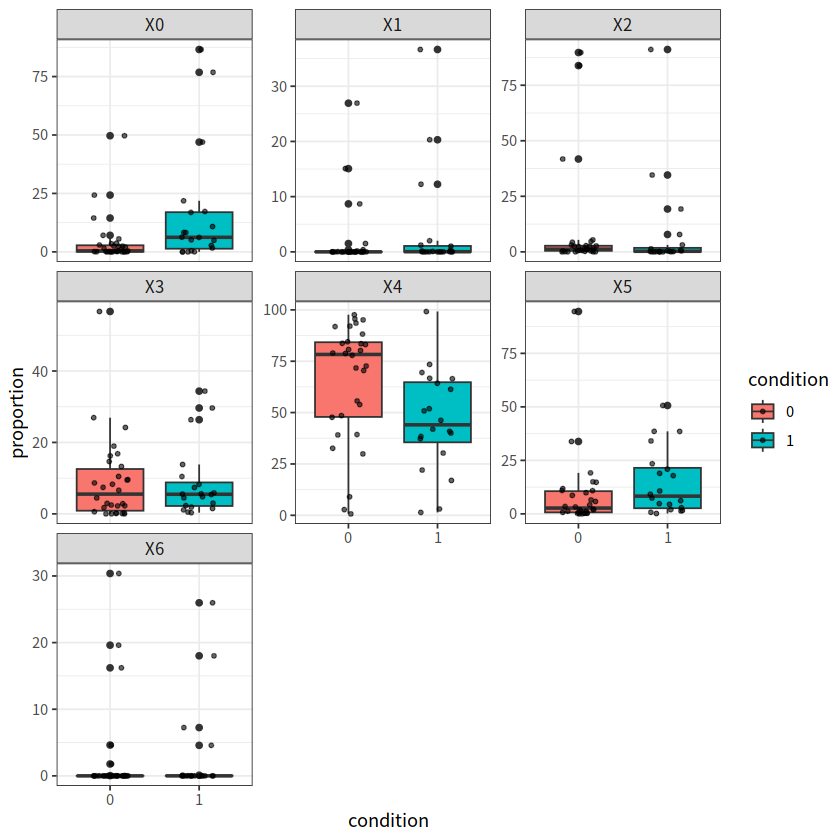

In [21]:
X=X1
celltypes <- colnames(X)
pvals <- c()
log2FC <- c()
for (ct in celltypes) {
  case_vals <- X[label == 1, ct]
  ctrl_vals <- X[label == 0, ct]
  # Wilcoxon test (自动处理 ties 警告)
  p <- wilcox.test(case_vals, ctrl_vals)$p.value
  # log2 fold change
  logfc <- log2(mean(case_vals + 1e-6) / mean(ctrl_vals + 1e-6))
  pvals <- c(pvals, p)
  log2FC <- c(log2FC, logfc)
}
results <- data.frame(
  celltype = celltypes,
  pvalue = pvals,
  log2FC = log2FC
)
results$FDR <- p.adjust(results$pvalue, method = "BH")
# 绘图
library(ggplot2)
library(ggrepel) # egg 通常不需要除非拼多图，这里只画一个图

results$log10FDR <- -log10(results$FDR)

ggplot(results, aes(x = log2FC, y = log10FDR, label = celltype)) +
  geom_point(size = 3) +
  geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "gray") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray") +
  geom_text_repel(max.overlaps = 20) + # 防止标签重叠
  theme_bw() +
  xlab("log2 Fold Change (Case vs Control)") +
  ylab("-log10(FDR)") +
  ggtitle("Volcano plot of cell type differences")


# --- 第二部分：单变量逻辑回归 (已修改：增加全0过滤和错误捕获) ---
logit_results <- data.frame()

for (ct in celltypes) {
  vals <- X[, ct]
  
  # 【必要修改 1】检查是否全为 0 或常数 (唯一值数量为 1)
  if (length(unique(vals)) == 1) {
    message(paste("跳过:", ct, "(数值无变化/全为0)"))
    next 
  }
  
  df <- data.frame(
    label = factor(label),
    value = vals
  )
  
  # 【必要修改 2】使用 tryCatch 防止模型不收敛导致脚本中断
  tryCatch({
    model <- glm(label ~ value, data = df, family = binomial)
    summary_model <- summary(model)
    
    beta <- summary_model$coefficients[2, 1]
    pval <- summary_model$coefficients[2, 4]
    
    # 额外检查：如果系数是 Inf 或 NaN，也跳过
    if (is.infinite(beta) || is.nan(pval)) {
      message(paste("跳过:", ct, "(系数发散)"))
      next
    }
    
    logit_results <- rbind(logit_results,
                           data.frame(celltype = ct,
                                      beta = beta,
                                      pvalue = pval,
                                      stringsAsFactors = FALSE))
  }, error = function(e) {
    message(paste("跳过:", ct, "(报错:", e$message, ")"))
  })
}

# 【必要修改 3】只有当有结果时才计算 FDR
if (nrow(logit_results) > 0) {
  logit_results$FDR <- p.adjust(logit_results$pvalue, method = "BH")
  print("逻辑回归完成，有效结果行数:")
  print(nrow(logit_results))
  print(head(logit_results[order(logit_results$FDR), ])) # 按 FDR 排序查看
} else {
  warning("所有细胞类型均未通过检查，logit_results 为空。")
}
# --- 第三部分：箱线图 (保持原样) ---
library(tidyr)
library(dplyr)
df_long <- X %>%
  mutate(sample = rownames(X),
         condition = label) %>%
  pivot_longer(cols = all_of(celltypes),
               names_to = "celltype",
               values_to = "proportion")

df_long$condition <- as.factor(df_long$condition)
ggplot(df_long, aes(x = condition, y = proportion, fill = condition)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  facet_wrap(~celltype, scales = "free_y") +
  theme_bw() +
  theme(strip.text = element_text(size = 10))

In [22]:
logit_results

celltype,beta,pvalue,FDR
<chr>,<dbl>,<dbl>,<dbl>
X0,0.047872858,0.07248394,0.2536938
X1,0.036691024,0.37065594,0.6486479
X2,-0.001152287,0.93175670,0.9317567
X3,-0.002708854,0.91952224,0.9317567
X4,-0.025791812,0.02368999,0.1658299
X5,0.021565942,0.25397131,0.5925997
X6,0.007912316,0.84964548,0.9317567


In [23]:
results

celltype,pvalue,log2FC,FDR,log10FDR
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
X0,0.01560639,1.94487748,0.05462235,1.2626296
X1,0.08110487,1.07272513,0.14193352,0.8479150
X2,0.12004876,-0.09330941,0.16806826,0.7745143
X3,0.74614740,-0.05193944,0.75455449,0.1223094
X4,0.00833016,-0.50275918,0.05462235,1.2626296
X5,0.03236756,0.73426097,0.07552431,1.1219133
X6,0.75455449,0.20748350,0.75455449,0.1223094


## CN10 and aderson

In [ ]:
X <- read.csv('/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/CN10_composition.txt', row.names = 1,sep='\t')
# label
label1 <- read.csv("/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 5 other figures in Fig1-4 Fig S1-6/anderson_adt.txt",sep='\t')
x_names_clean <- gsub("^m", "", gsub("\\.tsv$", "", rownames(X)))
common_ids <- intersect(x_names_clean, label1$Class)
cat("发现的重叠样本数量:", length(common_ids), "\n")
cat("示例重叠ID:", head(common_ids), "\n")
keep_indices <- which(x_names_clean %in% common_ids)
X1 <- X[keep_indices, ]
x1_names_clean <- gsub("^m", "", gsub("\\.tsv$", "", rownames(X1)))
labelnew <- label1[match(x1_names_clean, label1$Class), ]
# 重置行名，使其整洁
rownames(labelnew) <- NULL
# ---------------------------------------------------------
# 验证结果
# ---------------------------------------------------------
cat("\n--- 验证结果 ---\n")
cat("X1 行数:", nrow(X1), "\n")
cat("labelnew 行数:", nrow(labelnew), "\n")
# 检查前 5 个对应关系
if (nrow(X1) > 0) {
  check_df <- data.frame(
    X_Original_RowName = rownames(X1)[1:min(5, nrow(X1))],
    X_Clean_Name = x1_names_clean[1:min(5, nrow(X1))],
    Label_Class = labelnew$Class[1:min(5, nrow(labelnew))]
  )
  print(check_df)
  # 最终一致性检查
  if (all(x1_names_clean == labelnew$Class)) {
    cat("\n✅ 成功：X1 和 labelnew 已完美对齐 (ADT/mADT 匹配成功)！\n")
  } else {
    cat("\n❌ 错误：顺序或内容未对齐。\n")
  }
} else {
  cat("\n⚠️ 警告：没有找到任何匹配的样本。请检查 label1$Class 是否真的包含 'ADT-...' 格式。\n")
}
labelnew$Anderson[labelnew$Anderson == 1] = 0
labelnew$Anderson[labelnew$Anderson == 2] = 1
label= labelnew$Anderson

发现的重叠样本数量: 50 
示例重叠ID: ADT-1 ADT-10 ADT-11 ADT-12 ADT-13 ADT-14 

--- 验证结果 ---
X1 行数: 50 
labelnew 行数: 50 
  X_Original_RowName X_Clean_Name Label_Class
1         mADT-1.tsv        ADT-1       ADT-1
2        mADT-10.tsv       ADT-10      ADT-10
3        mADT-11.tsv       ADT-11      ADT-11
4        mADT-12.tsv       ADT-12      ADT-12
5        mADT-13.tsv       ADT-13      ADT-13

✅ 成功：X1 和 labelnew 已完美对齐 (ADT/mADT 匹配成功)！


Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”
Warning message in wilcox.test.default(case_vals, ctrl_vals):
“无法精確計算带连结的p值”


[1] "逻辑回归完成，有效结果行数:"
[1] 10
  celltype        beta     pvalue       FDR
1       X0  0.04825330 0.07303881 0.3651940
6       X8 -0.03025460 0.04066533 0.3651940
8       X6 -0.03417070 0.13300033 0.4433344
3       X3  0.02542275 0.18545045 0.4636261
7       X9  0.09414887 0.32030908 0.6406182
2       X2  0.03150983 0.43075028 0.7179171


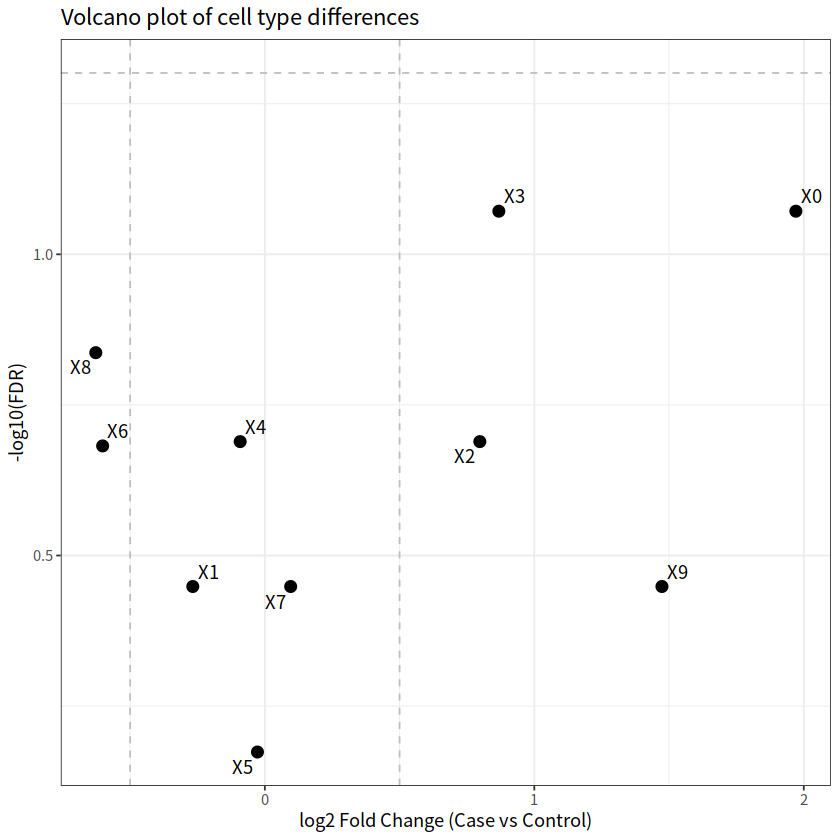

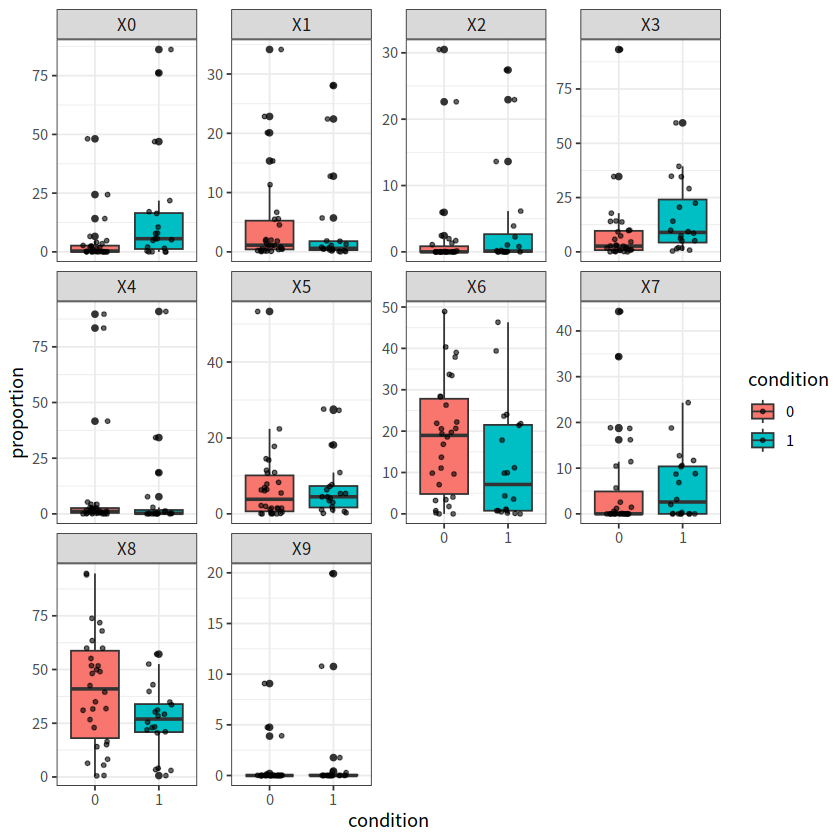

In [ ]:
X=X1
celltypes <- colnames(X)
pvals <- c()
log2FC <- c()
for (ct in celltypes) {
  case_vals <- X[label == 1, ct]
  ctrl_vals <- X[label == 0, ct]
  # Wilcoxon test (自动处理 ties 警告)
  p <- wilcox.test(case_vals, ctrl_vals)$p.value
  # log2 fold change
  logfc <- log2(mean(case_vals + 1e-6) / mean(ctrl_vals + 1e-6))
  pvals <- c(pvals, p)
  log2FC <- c(log2FC, logfc)
}
results <- data.frame(
  celltype = celltypes,
  pvalue = pvals,
  log2FC = log2FC
)
results$FDR <- p.adjust(results$pvalue, method = "BH")
# 绘图
library(ggplot2)
library(ggrepel) # egg 通常不需要除非拼多图，这里只画一个图

results$log10FDR <- -log10(results$FDR)

ggplot(results, aes(x = log2FC, y = log10FDR, label = celltype)) +
  geom_point(size = 3) +
  geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "gray") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray") +
  geom_text_repel(max.overlaps = 20) + # 防止标签重叠
  theme_bw() +
  xlab("log2 Fold Change (Case vs Control)") +
  ylab("-log10(FDR)") +
  ggtitle("Volcano plot of cell type differences")


# --- 第二部分：单变量逻辑回归 (已修改：增加全0过滤和错误捕获) ---
logit_results <- data.frame()

for (ct in celltypes) {
  vals <- X[, ct]
  
  # 【必要修改 1】检查是否全为 0 或常数 (唯一值数量为 1)
  if (length(unique(vals)) == 1) {
    message(paste("跳过:", ct, "(数值无变化/全为0)"))
    next 
  }
  
  df <- data.frame(
    label = factor(label),
    value = vals
  )
  
  # 【必要修改 2】使用 tryCatch 防止模型不收敛导致脚本中断
  tryCatch({
    model <- glm(label ~ value, data = df, family = binomial)
    summary_model <- summary(model)
    
    beta <- summary_model$coefficients[2, 1]
    pval <- summary_model$coefficients[2, 4]
    
    # 额外检查：如果系数是 Inf 或 NaN，也跳过
    if (is.infinite(beta) || is.nan(pval)) {
      message(paste("跳过:", ct, "(系数发散)"))
      next
    }
    
    logit_results <- rbind(logit_results,
                           data.frame(celltype = ct,
                                      beta = beta,
                                      pvalue = pval,
                                      stringsAsFactors = FALSE))
  }, error = function(e) {
    message(paste("跳过:", ct, "(报错:", e$message, ")"))
  })
}

# 【必要修改 3】只有当有结果时才计算 FDR
if (nrow(logit_results) > 0) {
  logit_results$FDR <- p.adjust(logit_results$pvalue, method = "BH")
  print("逻辑回归完成，有效结果行数:")
  print(nrow(logit_results))
  print(head(logit_results[order(logit_results$FDR), ])) # 按 FDR 排序查看
} else {
  warning("所有细胞类型均未通过检查，logit_results 为空。")
}
# --- 第三部分：箱线图 (保持原样) ---
library(tidyr)
library(dplyr)
df_long <- X %>%
  mutate(sample = rownames(X),
         condition = label) %>%
  pivot_longer(cols = all_of(celltypes),
               names_to = "celltype",
               values_to = "proportion")

df_long$condition <- as.factor(df_long$condition)
ggplot(df_long, aes(x = condition, y = proportion, fill = condition)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  facet_wrap(~celltype, scales = "free_y") +
  theme_bw() +
  theme(strip.text = element_text(size = 10))

In [ ]:
logit_results

celltype,beta,pvalue,FDR
<chr>,<dbl>,<dbl>,<dbl>
X0,0.048253301,0.07303881,0.3651940
X2,0.031509830,0.43075028,0.7179171
X3,0.025422750,0.18545045,0.4636261
X4,-0.001121221,0.93373326,0.9607706
X5,-0.001502465,0.96077061,0.9607706
X8,-0.030254604,0.04066533,0.3651940
X9,0.094148874,0.32030908,0.6406182
X6,-0.034170699,0.13300033,0.4433344
X7,0.004238416,0.88908220,0.9607706
